# __Sentiment Analysis using Machine Learning__

## Problem Statement:
Build a multi-class sentiment classification model to classify customer reviews into:
- Positive
- Neutral
- Negative

## Approach:
1. Data Cleaning
2. Text Preprocessing
3. Feature Engineering (TF-IDF)
4. Model Training
5. Hyperparameter Tuning
6. Evaluation

##### **Importing Required Libraries**

In [ ]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 300
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize


In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [42]:
from google.colab import files
uploaded = files.upload()

Saving dataset (2).csv to dataset (2).csv


In [ ]:
!rm -rf dataset.csv

In [43]:
!ls

'dataset (2).csv'   sample_data


In [48]:
data= pd.read_csv('dataset (2).csv')

In [49]:
data.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


## **Exploratory Data Analysis**

In [50]:
data.shape

(1440, 3)

In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [52]:
data.isna().sum()

,0
title,0
rating,0
body,0


In [53]:
data.duplicated().sum()

np.int64(0)

In [54]:
data.describe()

,rating
count,1440.000000
mean,3.173611
std,1.584453
min,1.000000
25%,1.000000
50%,4.000000
75%,5.000000
max,5.000000


In [55]:
data['rating'].unique()

array([1, 3, 4, 5, 2])

In [56]:
# Map rating to sentiment
def rating_to_sentiment(rating):
    if rating in [1, 2]:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

data['sentiment'] = data['rating'].apply(rating_to_sentiment)

In [57]:
data.head()

,title,rating,body,sentiment
0,Horrible product,1,Very disappointed with the overall performance...,Negative
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative


##### The 'Sentiment' column is newly generated, converting numeric ratings into categorical sentiment labels.

In [58]:
data['sentiment'].value_counts()

,count
sentiment,
Positive,729
Negative,512
Neutral,199


In [59]:
#Creating a new column 'review_length' that will contain the length of the body column
# review length = help the model understand extra information about the text beyond just the words.

data['review_length'] = data['body'].apply(len)

In [60]:
data

,title,rating,body,sentiment,review_length
0,Horrible product,1,Very disappointed with the overall performance...,Negative,59
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,21
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,403
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,377
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,179
...,...,...,...,...,...
1435,Excellent mobile,5,Excellent mobile,Positive,16
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve...",Negative,188
1437,Good value for money,5,Battery life is good but camera clarity could ...,Positive,98
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied.....",Negative,207


In [61]:
data.shape

(1440, 5)

In [62]:
data.dtypes

,0
title,object
rating,int64
body,object
sentiment,object
review_length,int64


Title, Body, and Sentiment are Object datatype

Rating, Review_length are integer datatype

# **Analysing** '**Rating**' **Column**

This column refers to the rating given by the user

In [63]:
data['rating'].value_counts()

,count
rating,
5,419
1,386
4,310
3,199
2,126


Text(0, 0.5, 'Count')

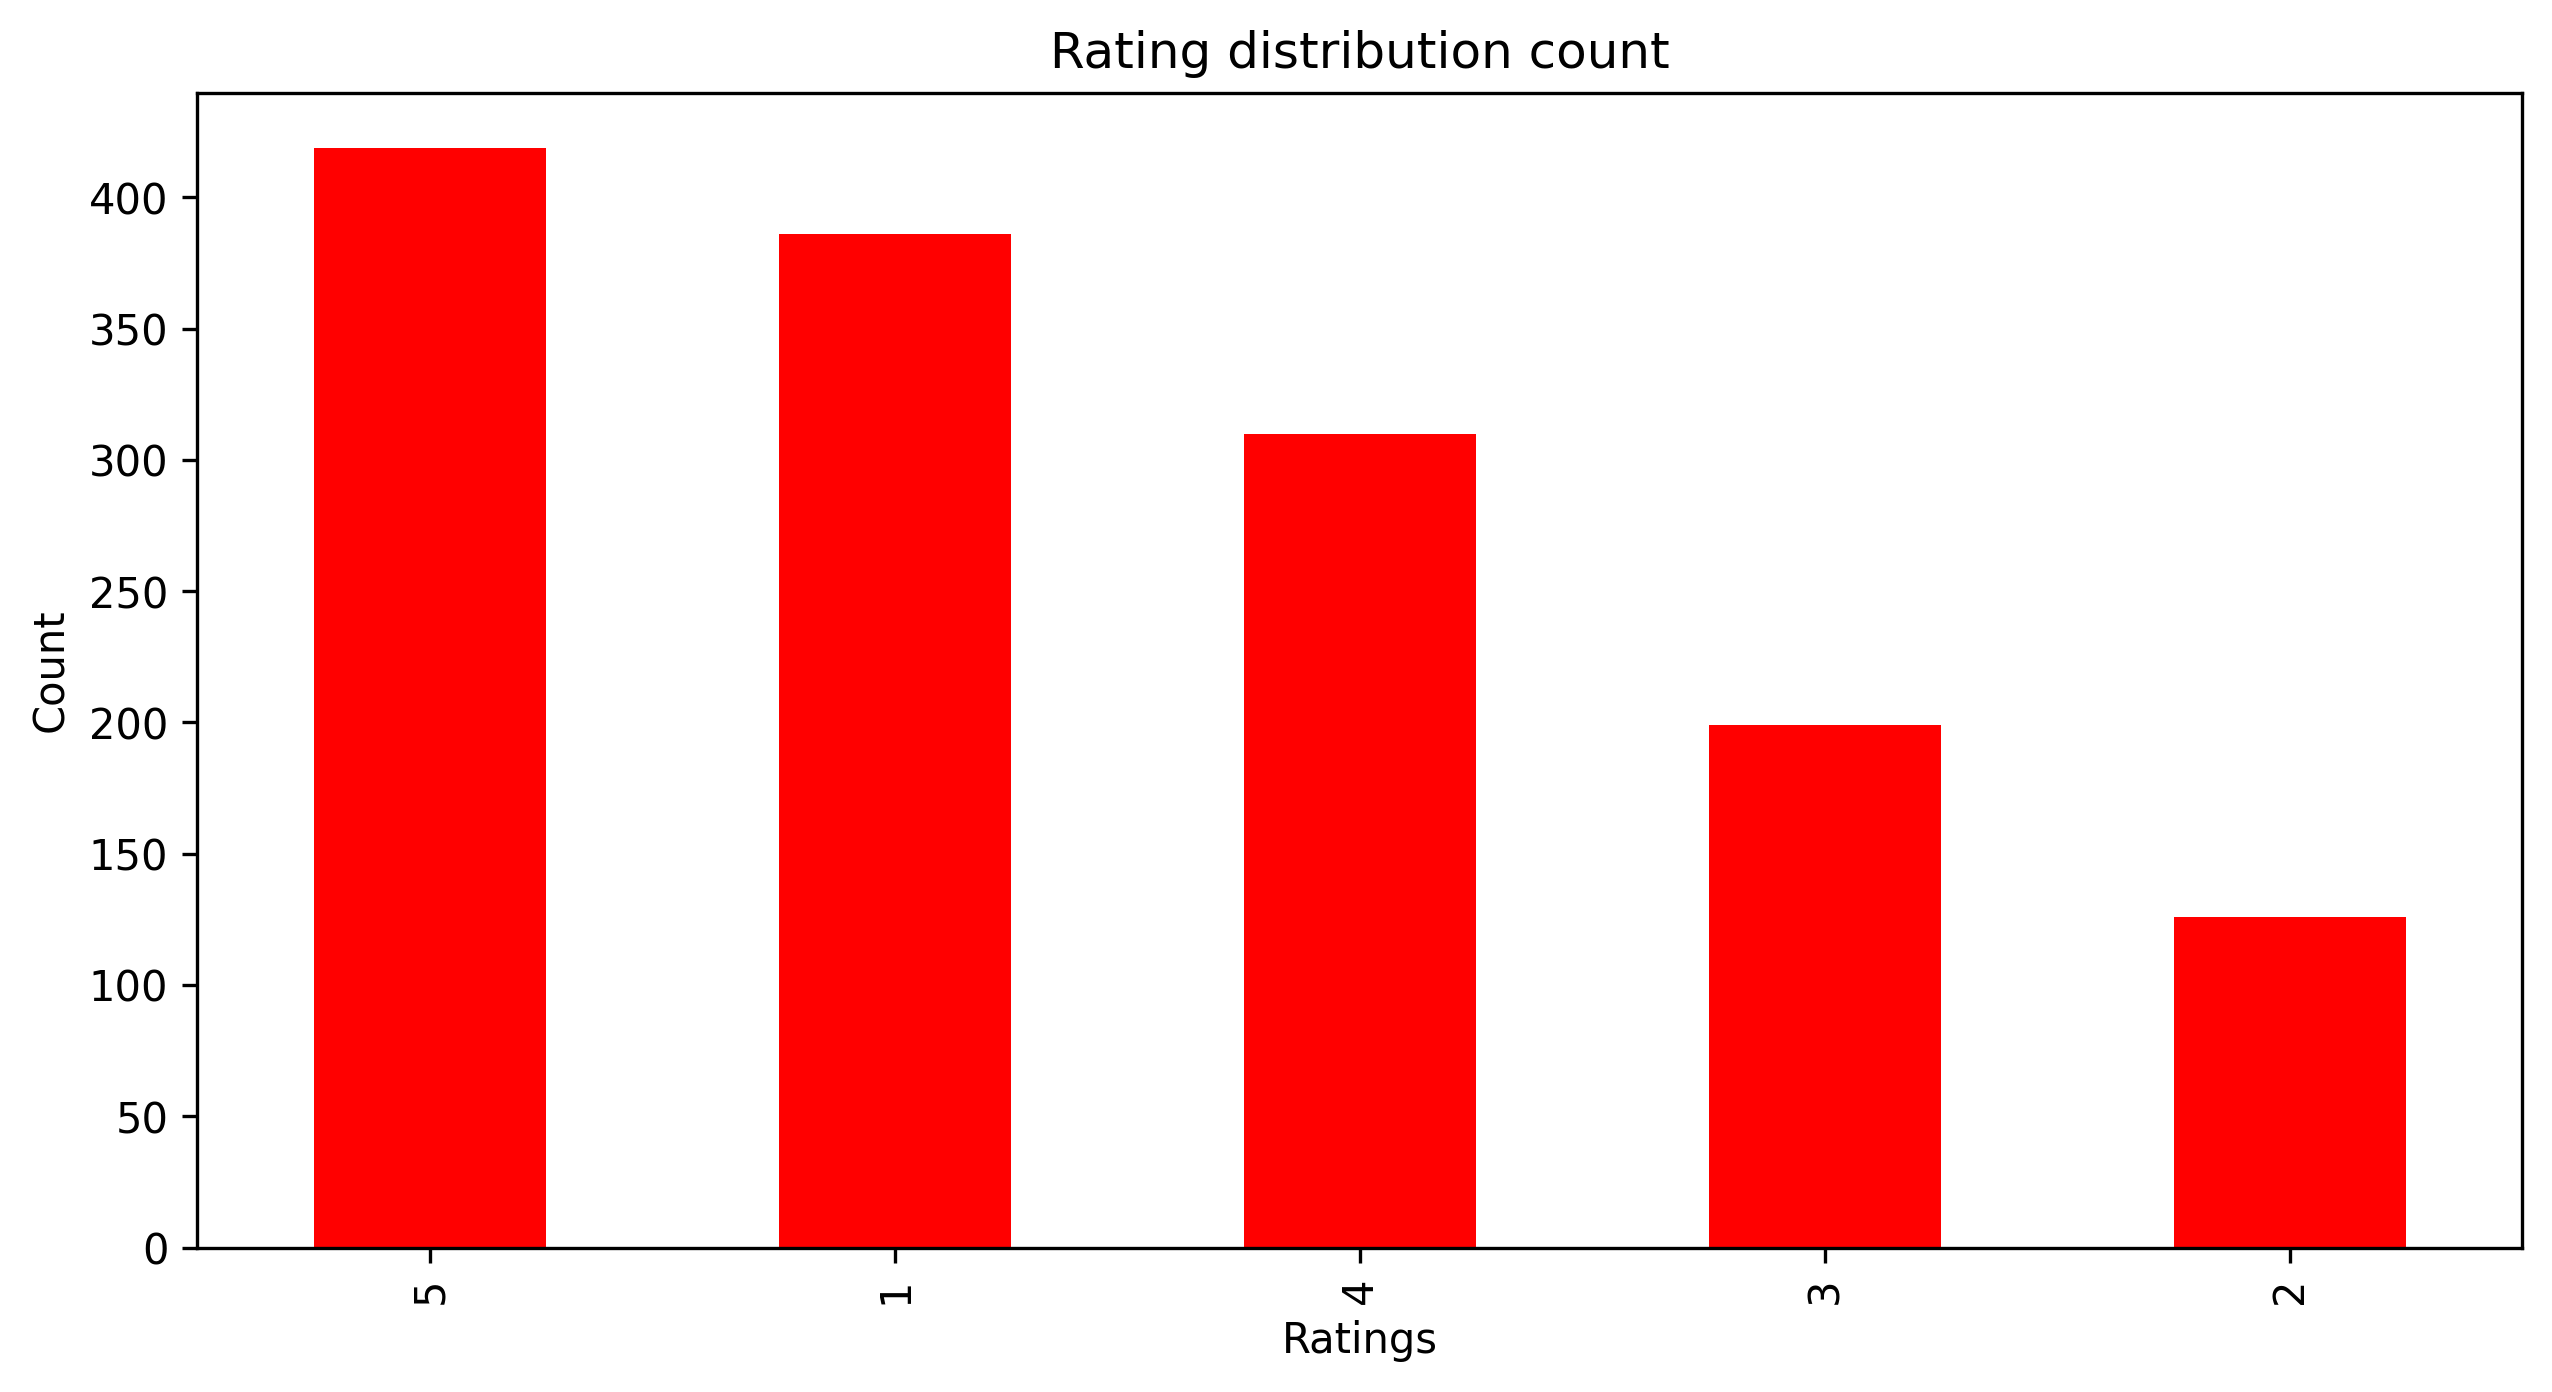

In [64]:
data['rating'].value_counts().plot.bar(color = 'red')
plt.title('Rating distribution count')
plt.xlabel('Ratings')
plt.ylabel('Count')

<Axes: ylabel='rating'>

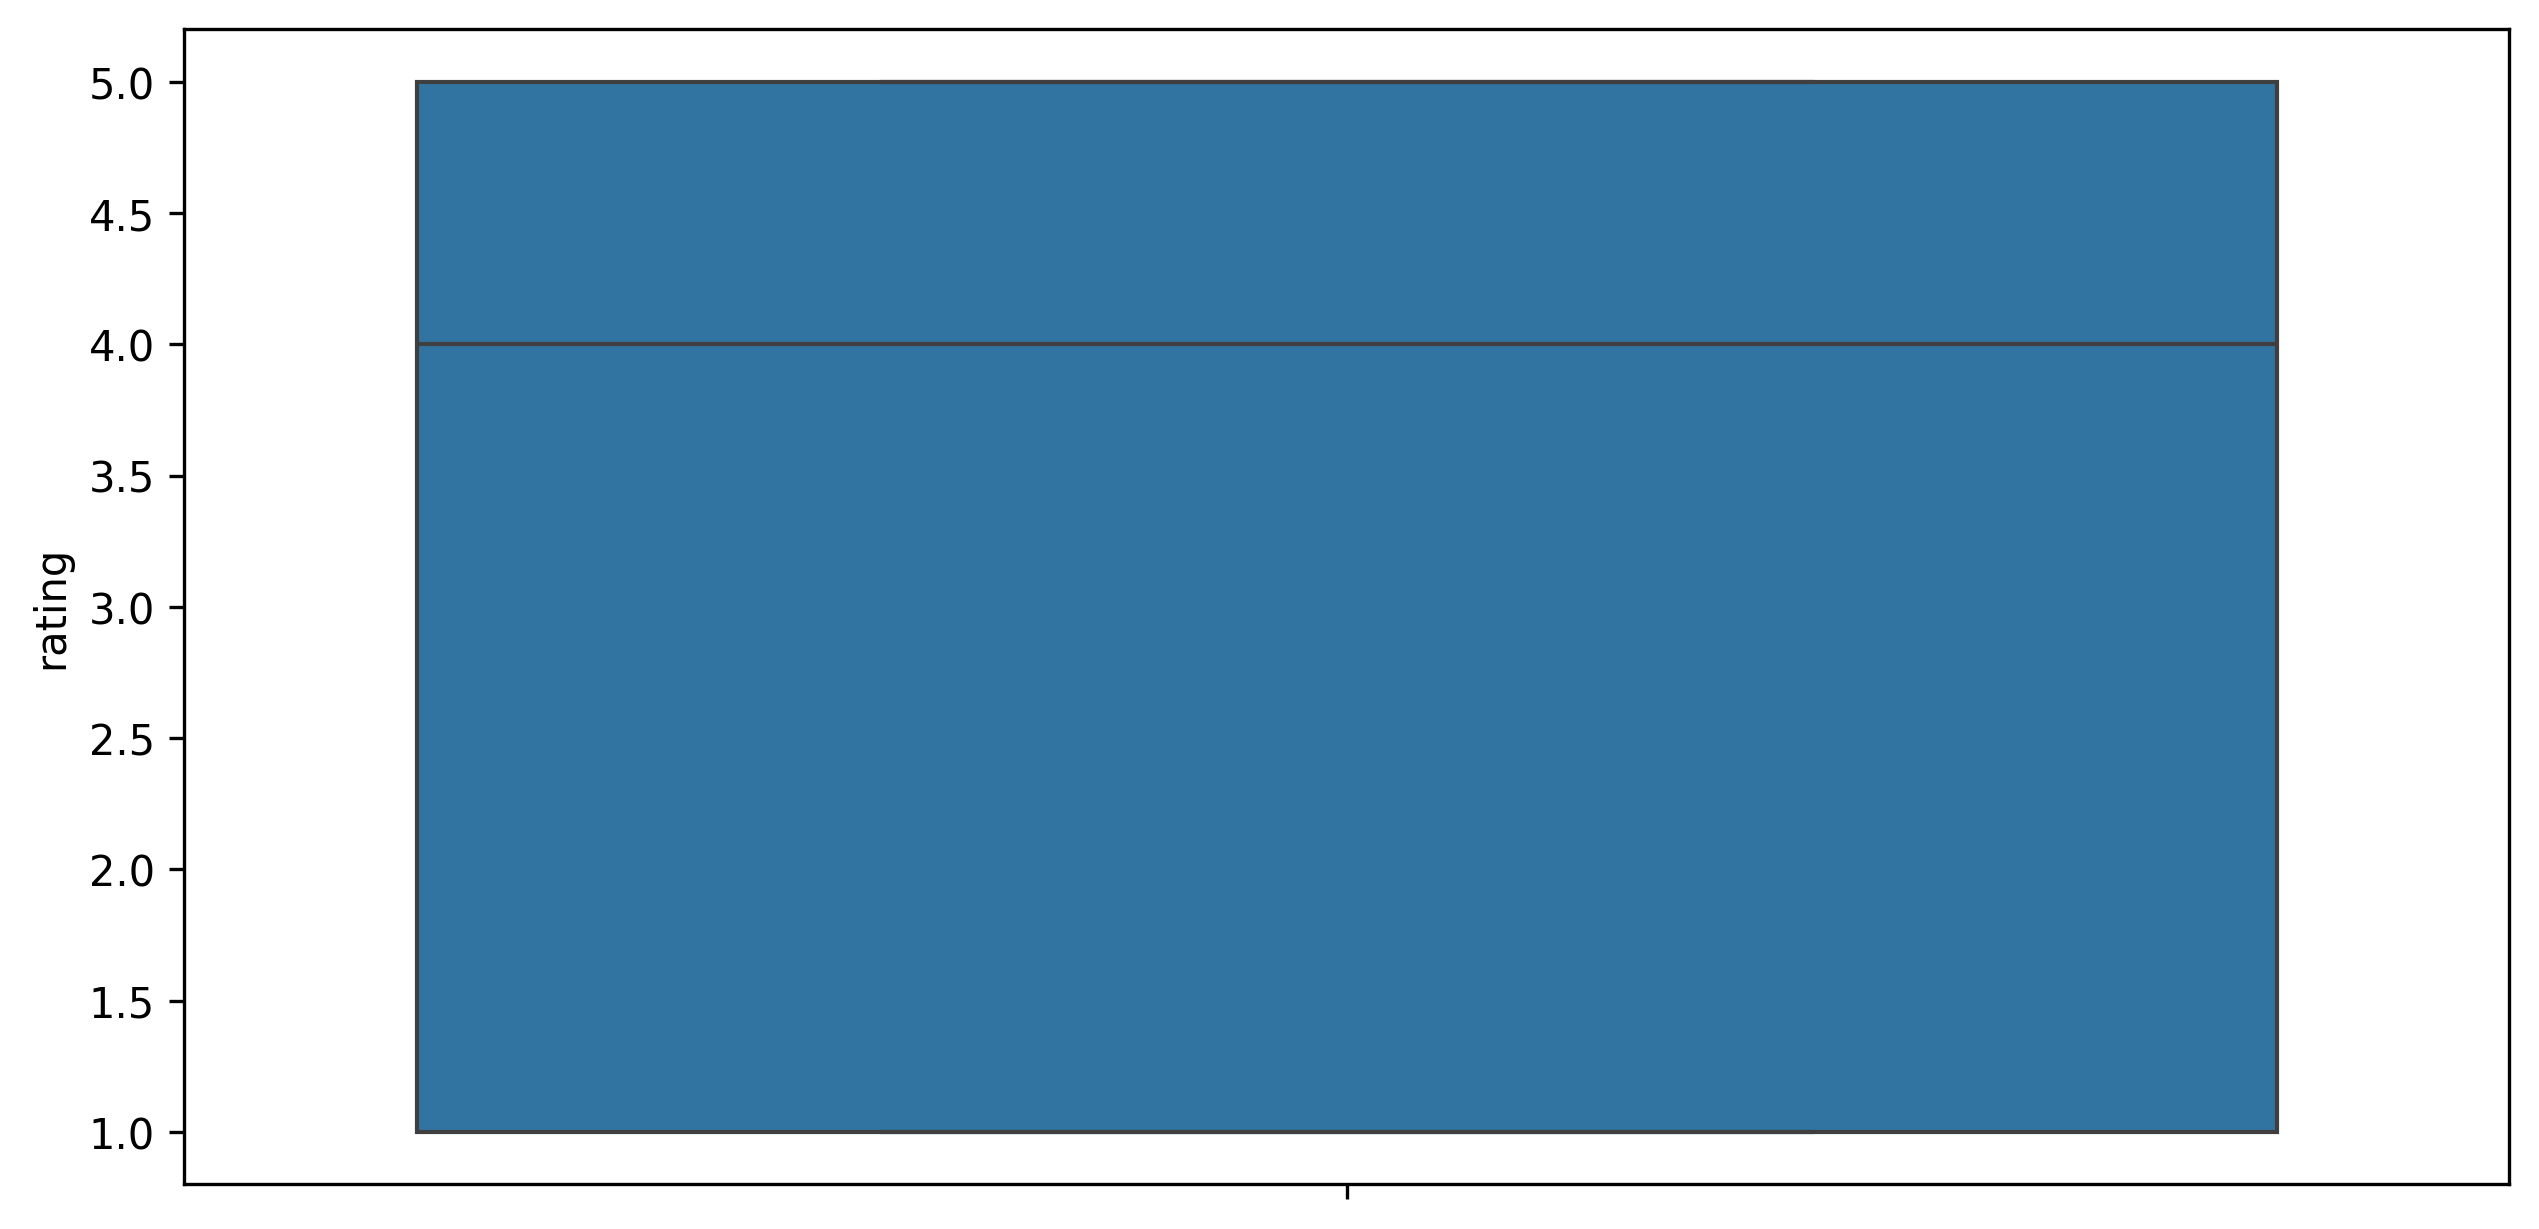

In [65]:
sns.boxplot(data['rating'])

# **Analyzing 'Body' Column**
This column contains the textual review given by the user for a variation of the product.

In [66]:
data['review_length'].describe()

,review_length
count,1440.000000
mean,302.109028
std,225.733052
min,4.000000
25%,170.000000
50%,246.000000
75%,359.000000
max,2490.000000


[Text(0.5, 1.0, 'Distribution of length of review')]

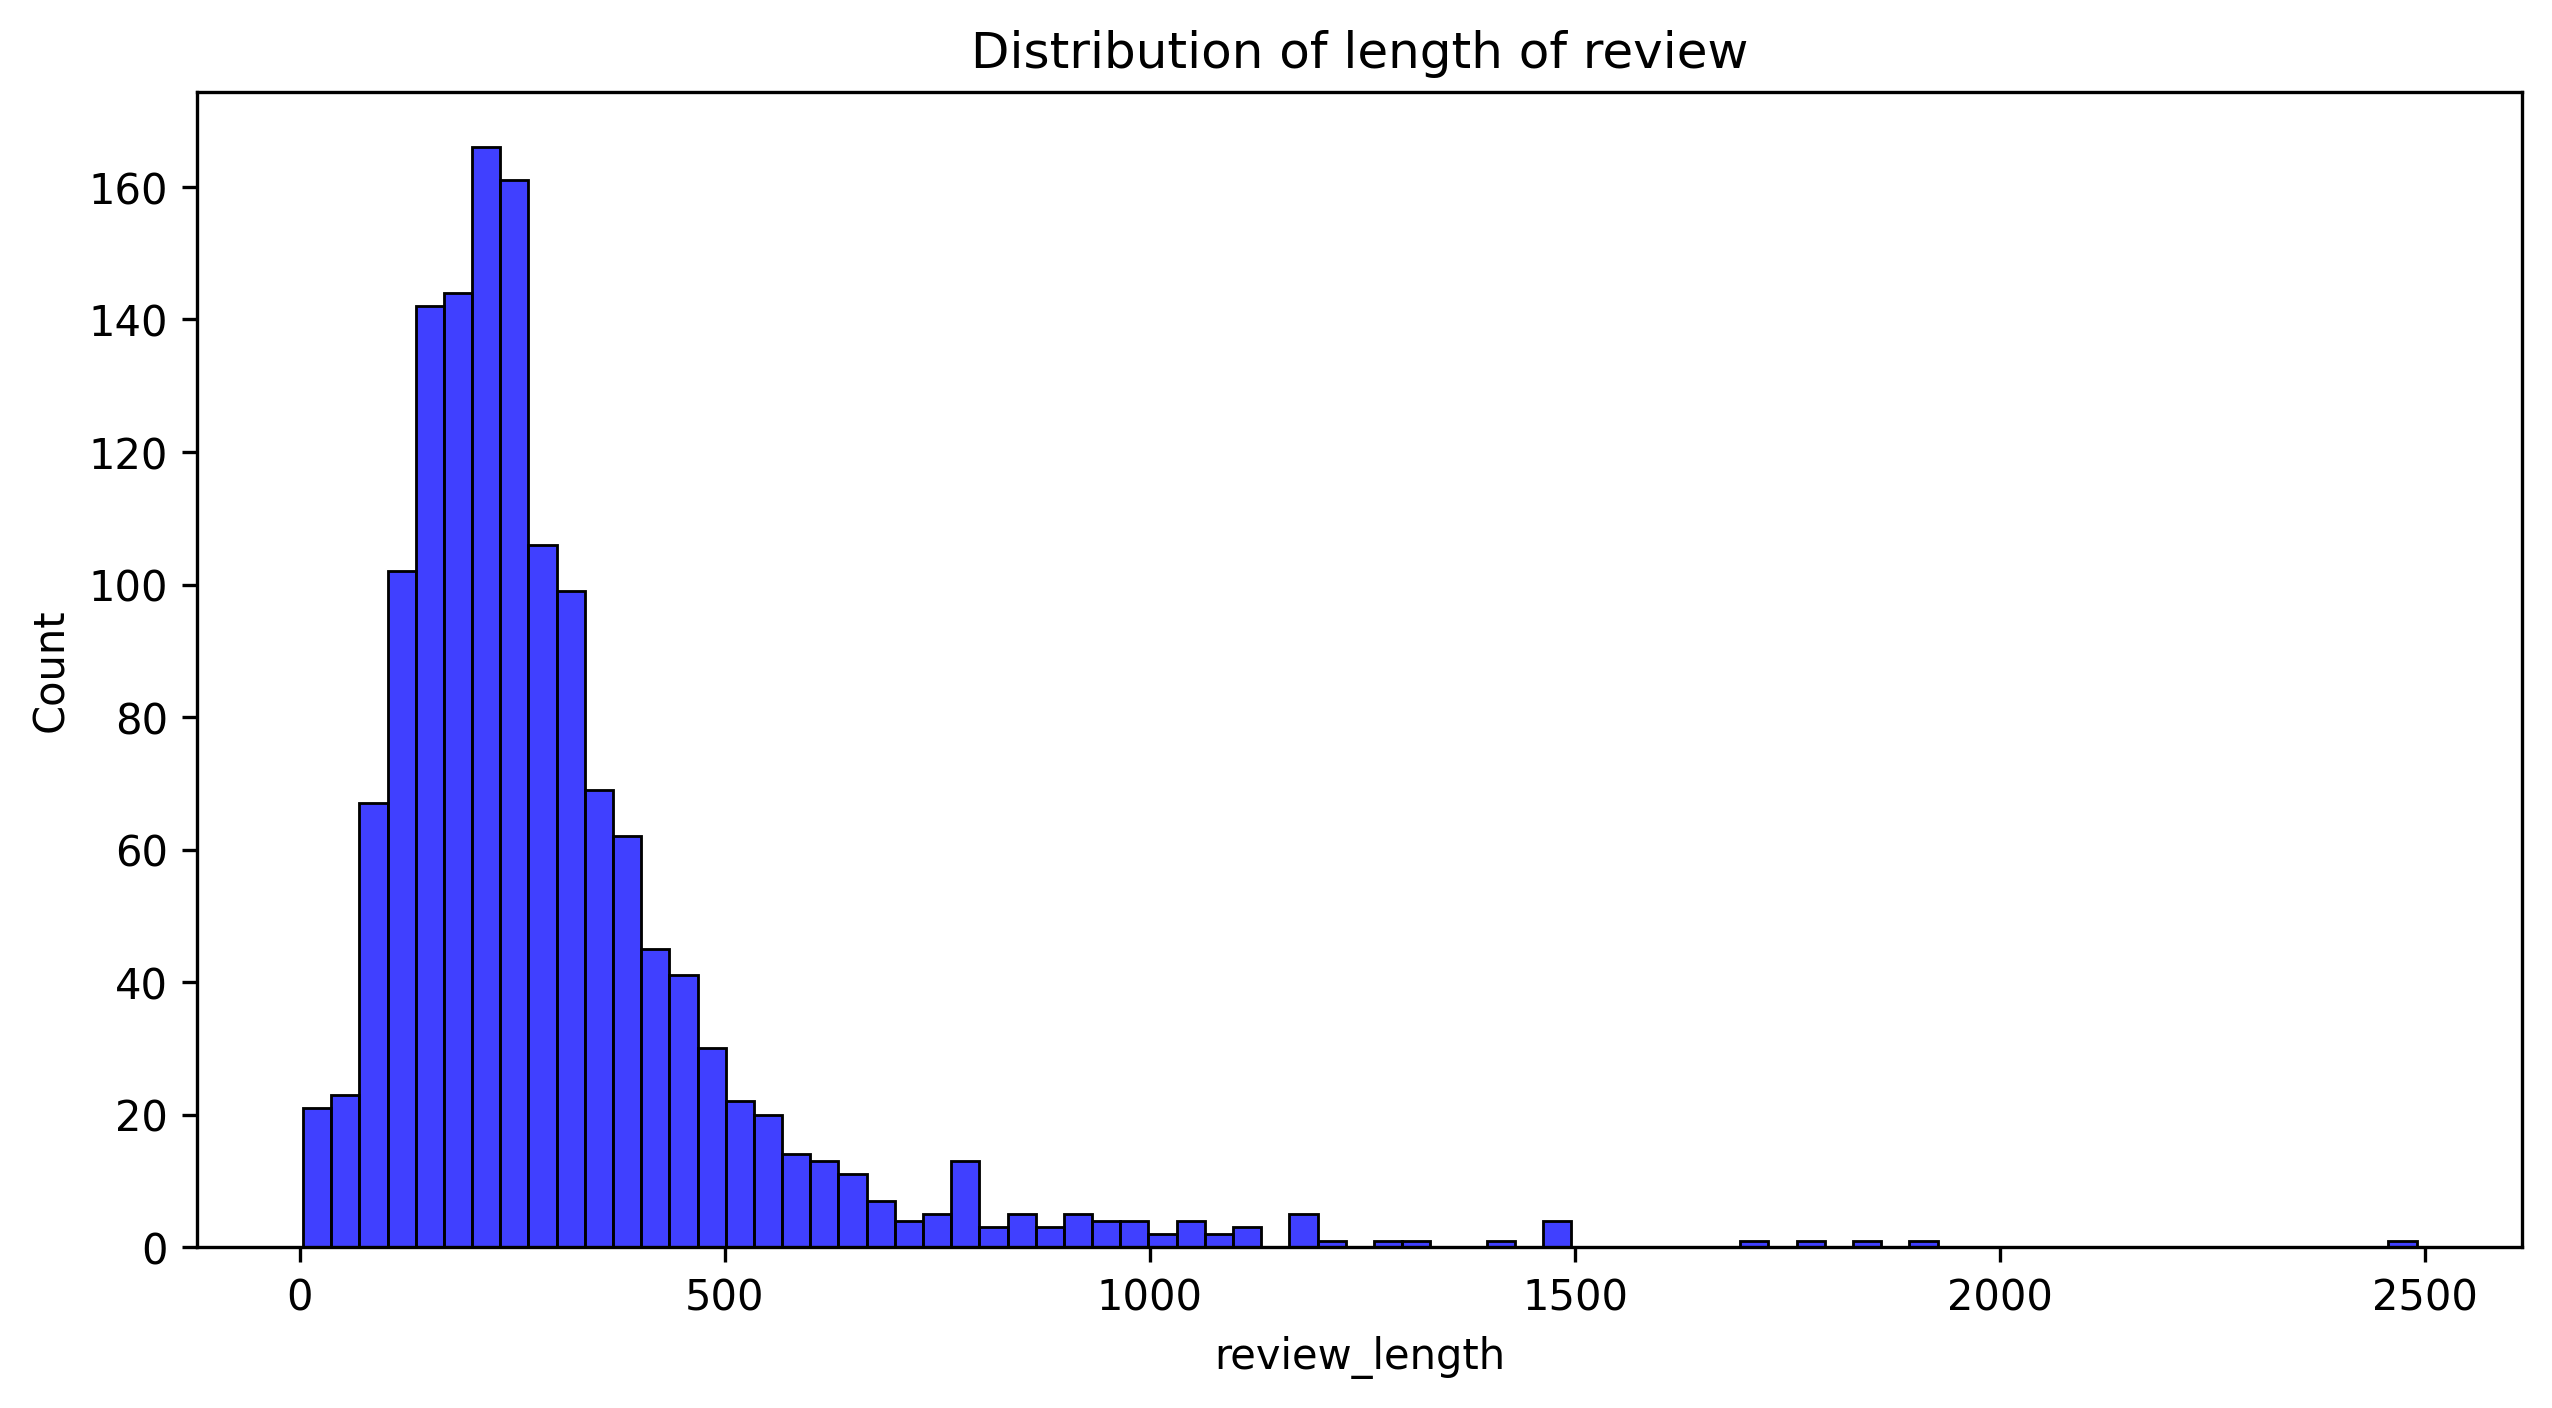

In [67]:
sns.histplot(data['review_length'], color='blue').set(title ="Distribution of length of review")

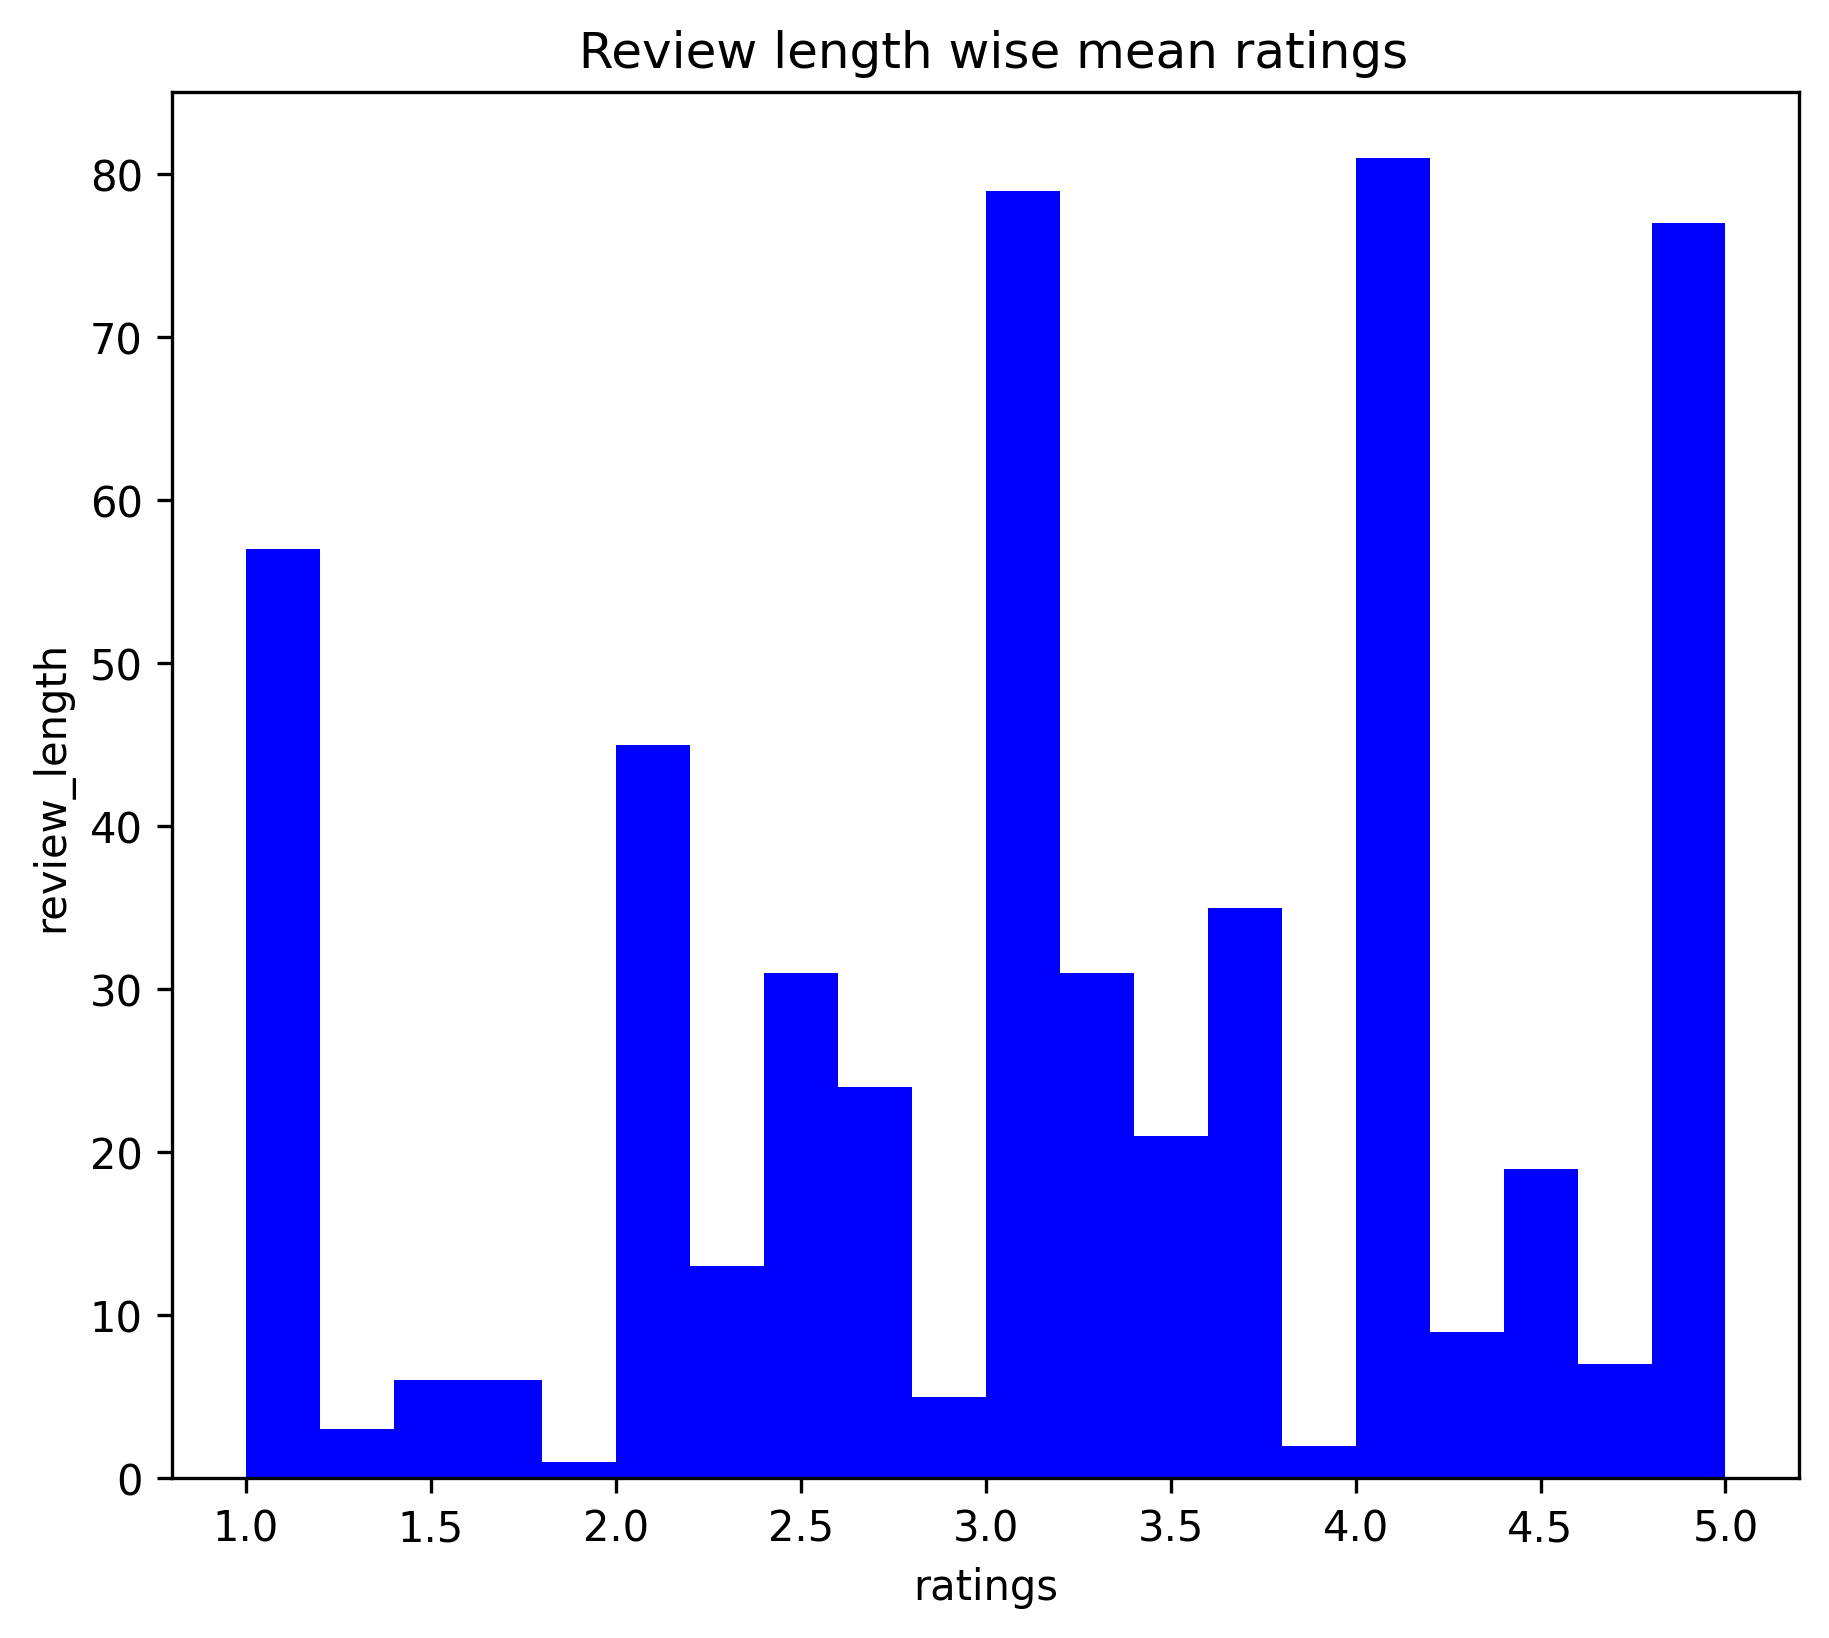

In [68]:
data.groupby('review_length')['rating'].mean().plot.hist(color= 'blue' , figsize=(7,6), bins = 20)
plt.title(" Review length wise mean ratings")
plt.xlabel('ratings')
plt.ylabel('review_length')
plt.show()

We calculate the mean of rating (not review_length)

How rating changes with review length.

<Axes: ylabel='review_length'>

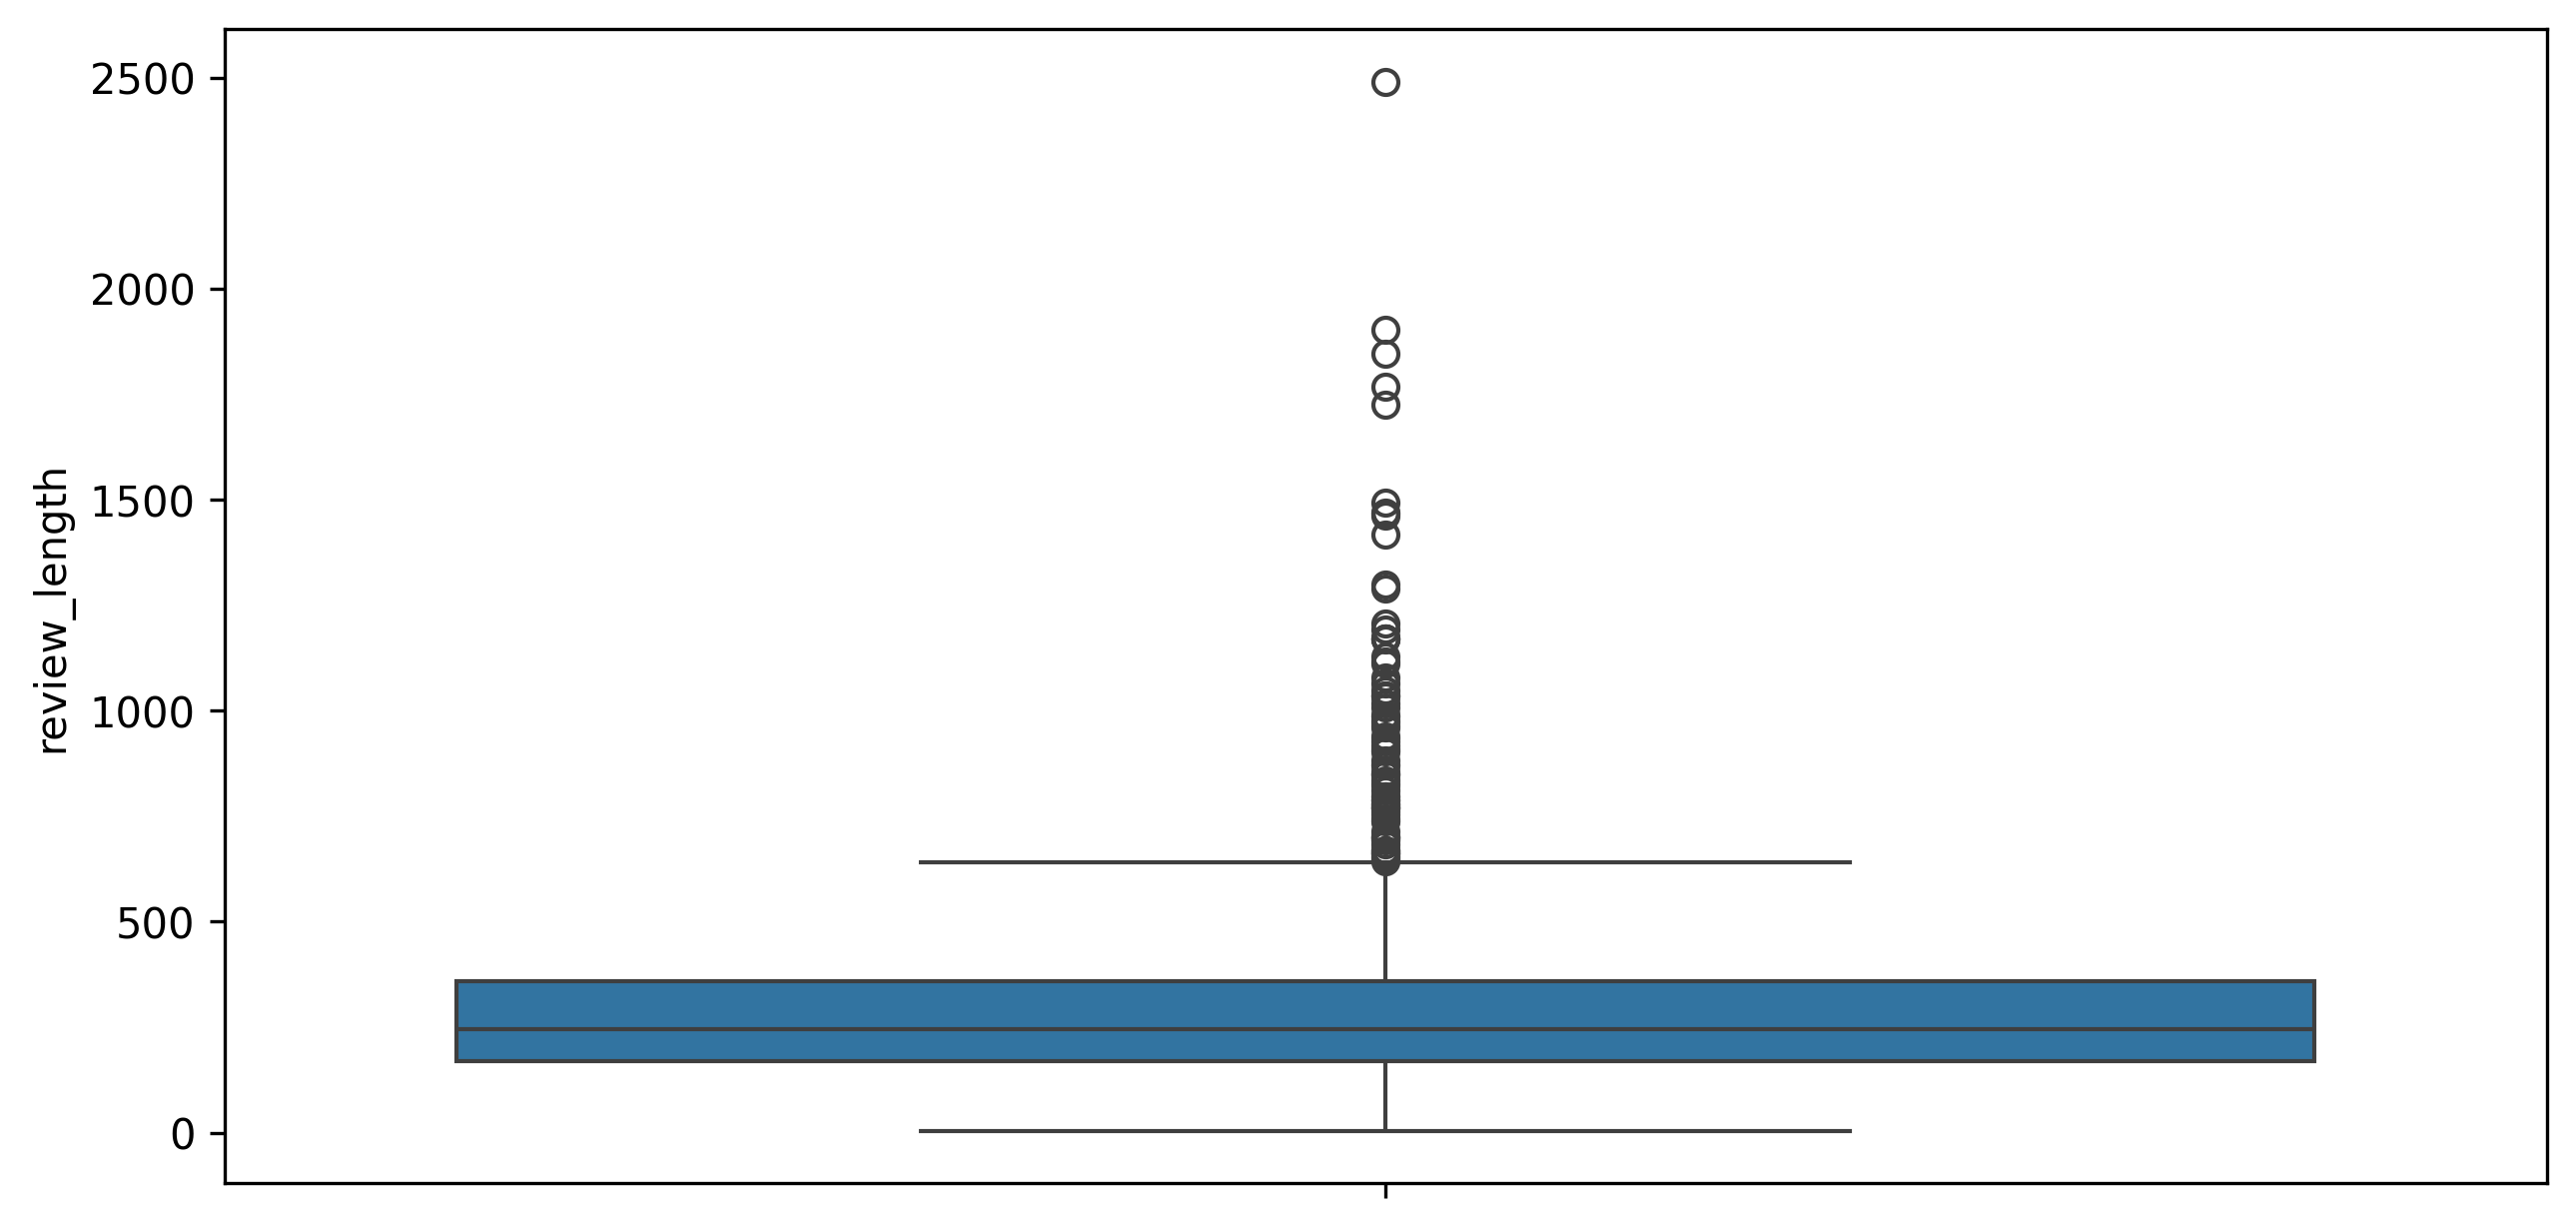

In [69]:
sns.boxplot(data['review_length'])

# **Analyzing 'Sentiment' Column**

In [70]:
data['sentiment'].value_counts()

,count
sentiment,
Positive,729
Negative,512
Neutral,199


In [71]:
(data['sentiment'].value_counts(normalize=True) * 100).round(2)

,proportion
sentiment,
Positive,50.62
Negative,35.56
Neutral,13.82


50.62% Reviews are Positive

35.56% Reviews are Negative

13.82% Reviews are Neutral

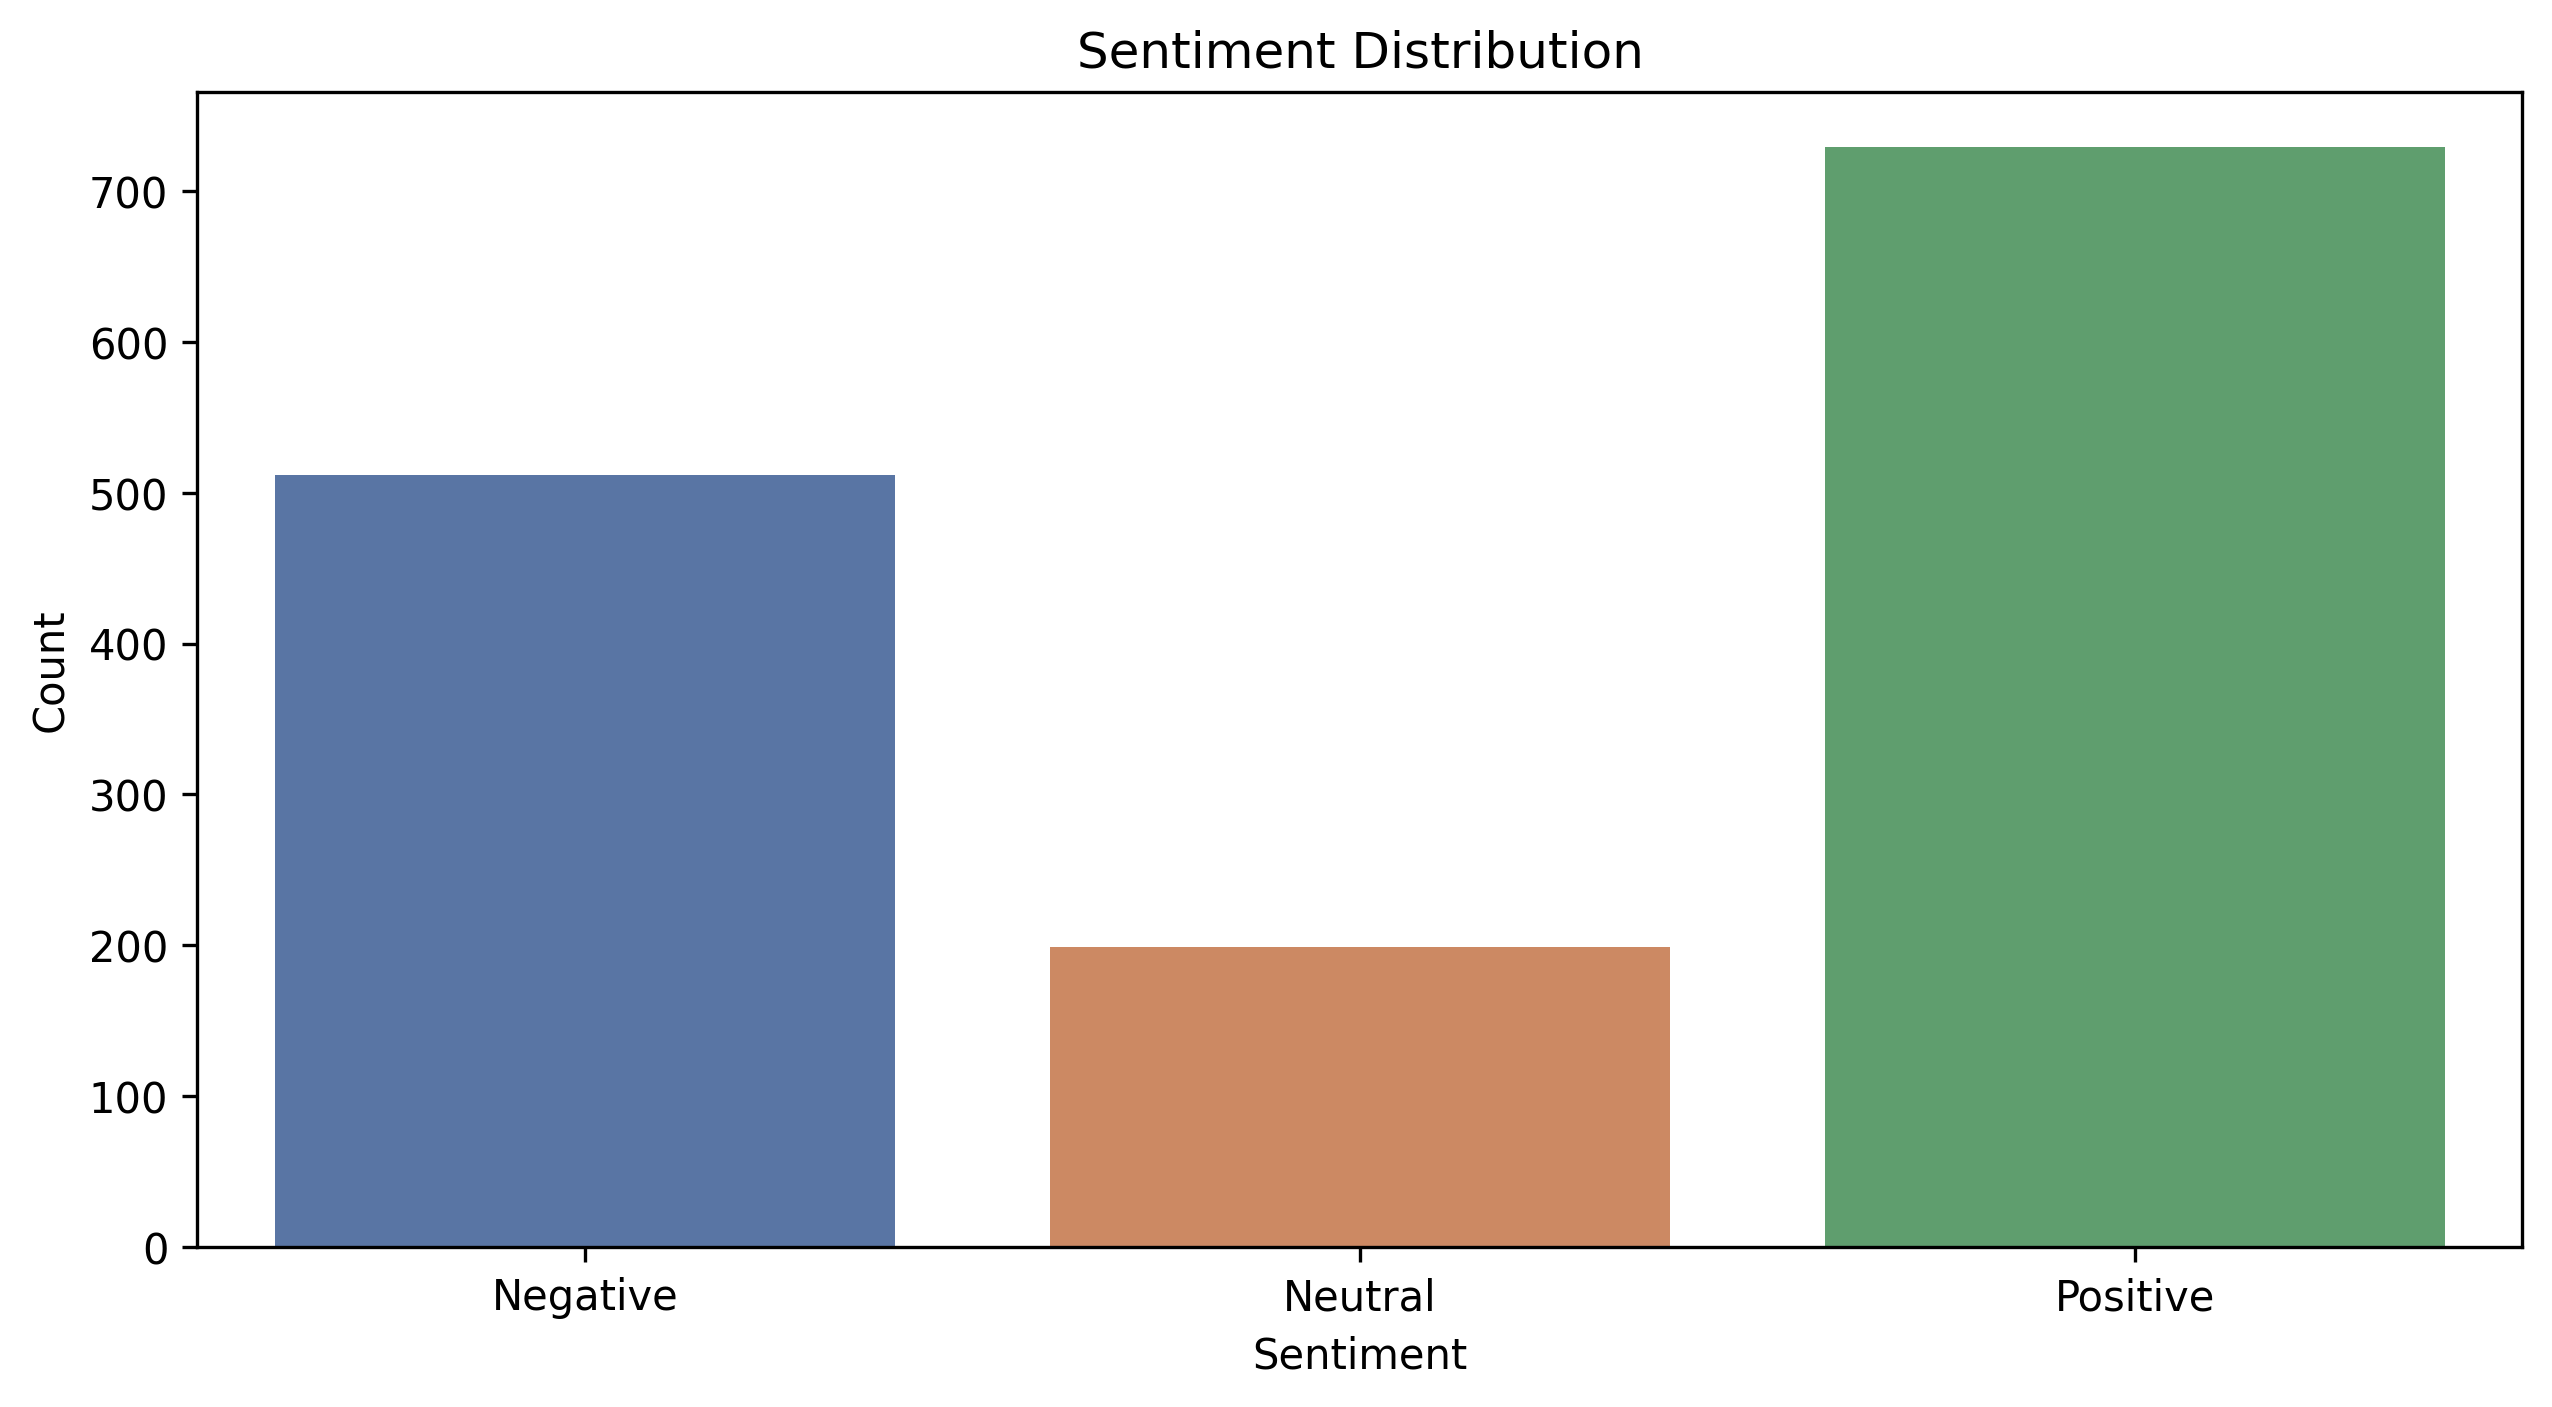

In [72]:
sns.countplot(x='sentiment', data=data,  palette='deep')
#colors = ['#66c2a5', '#fc8d62', '#8da0cb']
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [73]:
from wordcloud import WordCloud

# Generate word clouds for each sentiment
for sentiment in data['sentiment'].unique():
    text = " ".join(data[data['sentiment']==sentiment]['body'].astype(str))

    # Initialize wordcloud object
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)

    # Generate and plot wordcloud
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud for {sentiment} Reviews")
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Preprocessing And Modelling

# Text cleaning
1. Remove unwanted characters
2. Text normalization
3. Tokenization
4. lemmatization
5. Join the text

In [74]:
data

,title,rating,body,sentiment,review_length
0,Horrible product,1,Very disappointed with the overall performance...,Negative,59
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,21
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,403
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,377
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,179
...,...,...,...,...,...
1435,Excellent mobile,5,Excellent mobile,Positive,16
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve...",Negative,188
1437,Good value for money,5,Battery life is good but camera clarity could ...,Positive,98
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied.....",Negative,207


In [75]:
lemma = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [76]:
corpus = []

for text in data['body']:
    review = re.sub('[^a-zA-Z]', ' ', text)
    review = review.lower()
    review = review.split()

    review = [lemma.lemmatize(word) for word in review
              if word not in stop_words and len(word) > 2]

    review = ' '.join(review)
    corpus.append(review)

In [77]:
corpus

['disappointed overall performance samsung',
 'camera quality low',
 'got mobile launch date battery must appreciatedcamera averagemobile performance average refresh rate buying mobile feature afraid may get disappointed normal usb cable small lengthit good mobile budget return replacement available hence choose wisely buying',
 'work ghz wifi frequency ghz old school camera quality pathetic front back forget picture blur poorer one amazon allow write review sold stock something fishy return policy live phone like decide',
 'worth buying faulty software poor display quality single band wifi support ghz wifi band gyro sensor missing many dont paid review tube',
 'never purchase samsung phone phone lagging much slow waste hard earning money',
 'worst samsung mobile seen samsung sceen quality color trash even old phone beat quality please never ever buy product',
 '',
 'phone hang lot slow received replacement continues hang',
 'poor quality camera found box seal damage still amazon takin

In [78]:
print(corpus[:5])  # stop words get removed

['disappointed overall performance samsung', 'camera quality low', 'got mobile launch date battery must appreciatedcamera averagemobile performance average refresh rate buying mobile feature afraid may get disappointed normal usb cable small lengthit good mobile budget return replacement available hence choose wisely buying', 'work ghz wifi frequency ghz old school camera quality pathetic front back forget picture blur poorer one amazon allow write review sold stock something fishy return policy live phone like decide', 'worth buying faulty software poor display quality single band wifi support ghz wifi band gyro sensor missing many dont paid review tube']


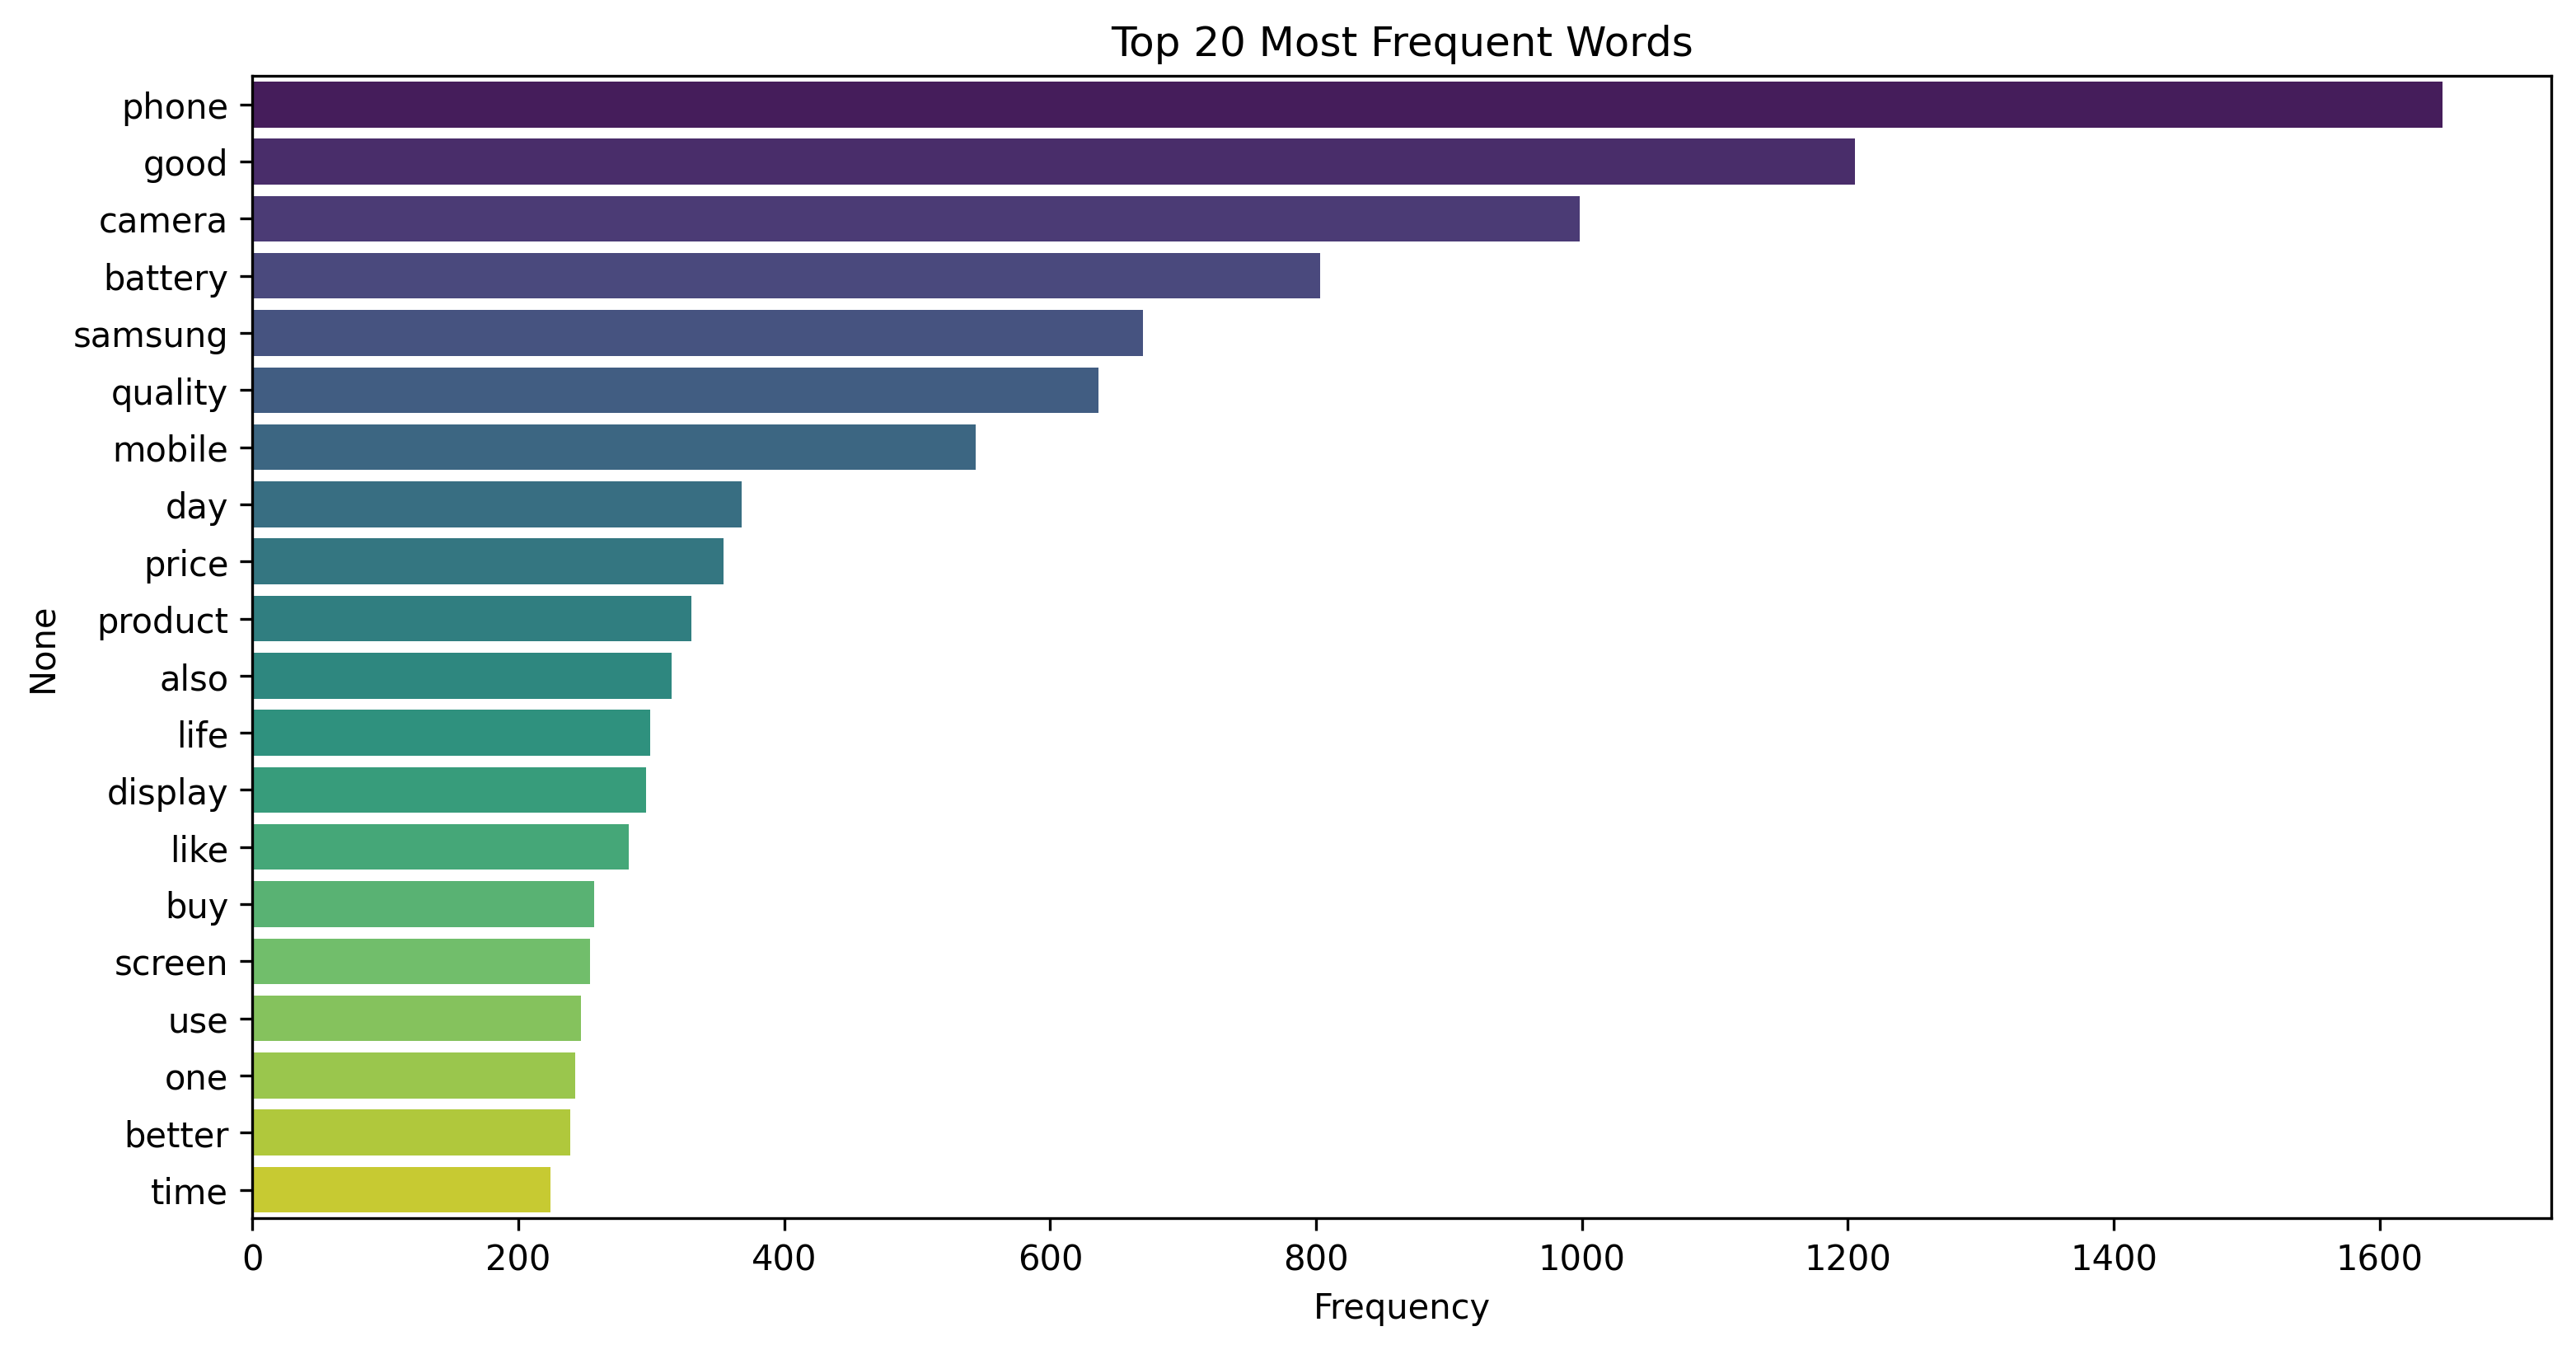

In [79]:

# Calculate word frequencies
word_freq = pd.Series(" ".join(corpus).split()).value_counts()[:20]

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=word_freq.values, y=word_freq.index, palette='viridis')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.show()

## Feature Extraction

In [80]:
data

,title,rating,body,sentiment,review_length
0,Horrible product,1,Very disappointed with the overall performance...,Negative,59
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,21
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,403
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,377
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,179
...,...,...,...,...,...
1435,Excellent mobile,5,Excellent mobile,Positive,16
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve...",Negative,188
1437,Good value for money,5,Battery life is good but camera clarity could ...,Positive,98
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied.....",Negative,207


In [81]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(data['sentiment'])

In [82]:
y

array([0, 1, 2, ..., 2, 0, 2])

In [83]:
y.shape

(1440,)

In [84]:
# Split first
x_train_raw, x_test_raw, y_train, y_test = train_test_split(corpus, y, test_size=0.2, random_state=42)

# Fit TF-IDF only on training data
tfidf = TfidfVectorizer(max_features=5000)
x_train = tfidf.fit_transform(x_train_raw)

# Transform test data
x_test = tfidf.transform(x_test_raw)

In [85]:
print(type(x_train_raw))

<class 'list'>


In [86]:
print(x_train_raw)

['like product battery life finger print reader camera quality', 'device awesome get got miner lag get heat quickly use gaming camera outstandingdisplay goodsound goodlooks goodprocesser avg know last least battery like big monster last upto day', 'first phone worth purchaseand best budget promise samsung normal user epecially middle aged one new android experiencing one better choise branded non chinese mobile perfomance camera quality primary camera best give awesome click impressed secondary repeat budget based handset samsung finger print reader take second time wide range fast battery life awesome word say fast charging negative portion weight weight heavier noted samsung introduced model specification perfomance carrying monster typical battery mah weighing around lite weight easy handle remember prize difference overall conclusion product worth money completely satisfied much money expectation thank samsung especially thankyou amazon best service', 'superb great speed photo clar

In [87]:
print(type(x_train))

<class 'scipy.sparse._csr.csr_matrix'>


In [88]:
print(x_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 27658 stored elements and shape (1152, 3946)>
  Coords	Values
  (0, 1969)	0.3213631413222844
  (0, 2675)	0.30805531014423226
  (0, 307)	0.20777128524425054
  (0, 1954)	0.2956540660573328
  (0, 1297)	0.42389753204527897
  (0, 2642)	0.44190955077943994
  (0, 2792)	0.44923888359133335
  (0, 509)	0.1935703842543185
  (0, 2735)	0.23872408049506882
  (1, 1969)	0.10736912656041468
  (1, 307)	0.0694174861784718
  (1, 509)	0.06467288998929395
  (1, 936)	0.15552272827373026
  (1, 257)	0.1421357155247745
  (1, 1435)	0.25488228397946516
  (1, 1500)	0.13870629579511132
  (1, 2166)	0.2791438664161094
  (1, 1895)	0.16643817685072176
  (1, 1596)	0.18331077921182345
  (1, 2752)	0.2316105959372462
  (1, 3720)	0.11359591179616242
  (1, 1411)	0.15777741618281674
  (1, 2418)	0.2791438664161094
  (1, 1487)	0.2791438664161094
  (1, 1476)	0.2791438664161094
  :	:
  (1150, 2047)	0.25575903603110617
  (1150, 850)	0.2706768541366705
  (1150, 1486)	0.2

In [89]:
print(x_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6999 stored elements and shape (288, 3946)>
  Coords	Values
  (0, 106)	0.1675472369473532
  (0, 113)	0.09123616277065753
  (0, 116)	0.0679294863016633
  (0, 307)	0.07520244099924053
  (0, 693)	0.09297401725124155
  (0, 702)	0.11812549918168268
  (0, 854)	0.11189721275690306
  (0, 901)	0.10287693050046193
  (0, 903)	0.3116390515974333
  (0, 1168)	0.1038796838658111
  (0, 1194)	0.3265841074545951
  (0, 1268)	0.07538805323406796
  (0, 1420)	0.13695744268231
  (0, 1448)	0.0809608845161884
  (0, 1532)	0.11121019825244591
  (0, 1543)	0.10287693050046193
  (0, 1570)	0.08814750776354388
  (0, 1613)	0.13695744268231
  (0, 1652)	0.0850477403651838
  (0, 1655)	0.10979223142969868
  (0, 1908)	0.1545399516212044
  (0, 1930)	0.1127332925018993
  (0, 1954)	0.10701145460367407
  (0, 1969)	0.05815840395415865
  (0, 2009)	0.08721314836184314
  :	:
  (286, 1463)	0.3717062238422923
  (286, 1652)	0.24577630476219875
  (286, 1853)	0.3717062238422

# Model Building

 **1**. **Logistic Regression**

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [91]:
model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [92]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7743055555555556


In [93]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       111
           1       1.00      0.05      0.09        44
           2       0.73      0.95      0.82       133

    accuracy                           0.77       288
   macro avg       0.86      0.62      0.59       288
weighted avg       0.81      0.77      0.72       288



In [94]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 94   0  17]
 [ 11   2  31]
 [  6   0 127]]


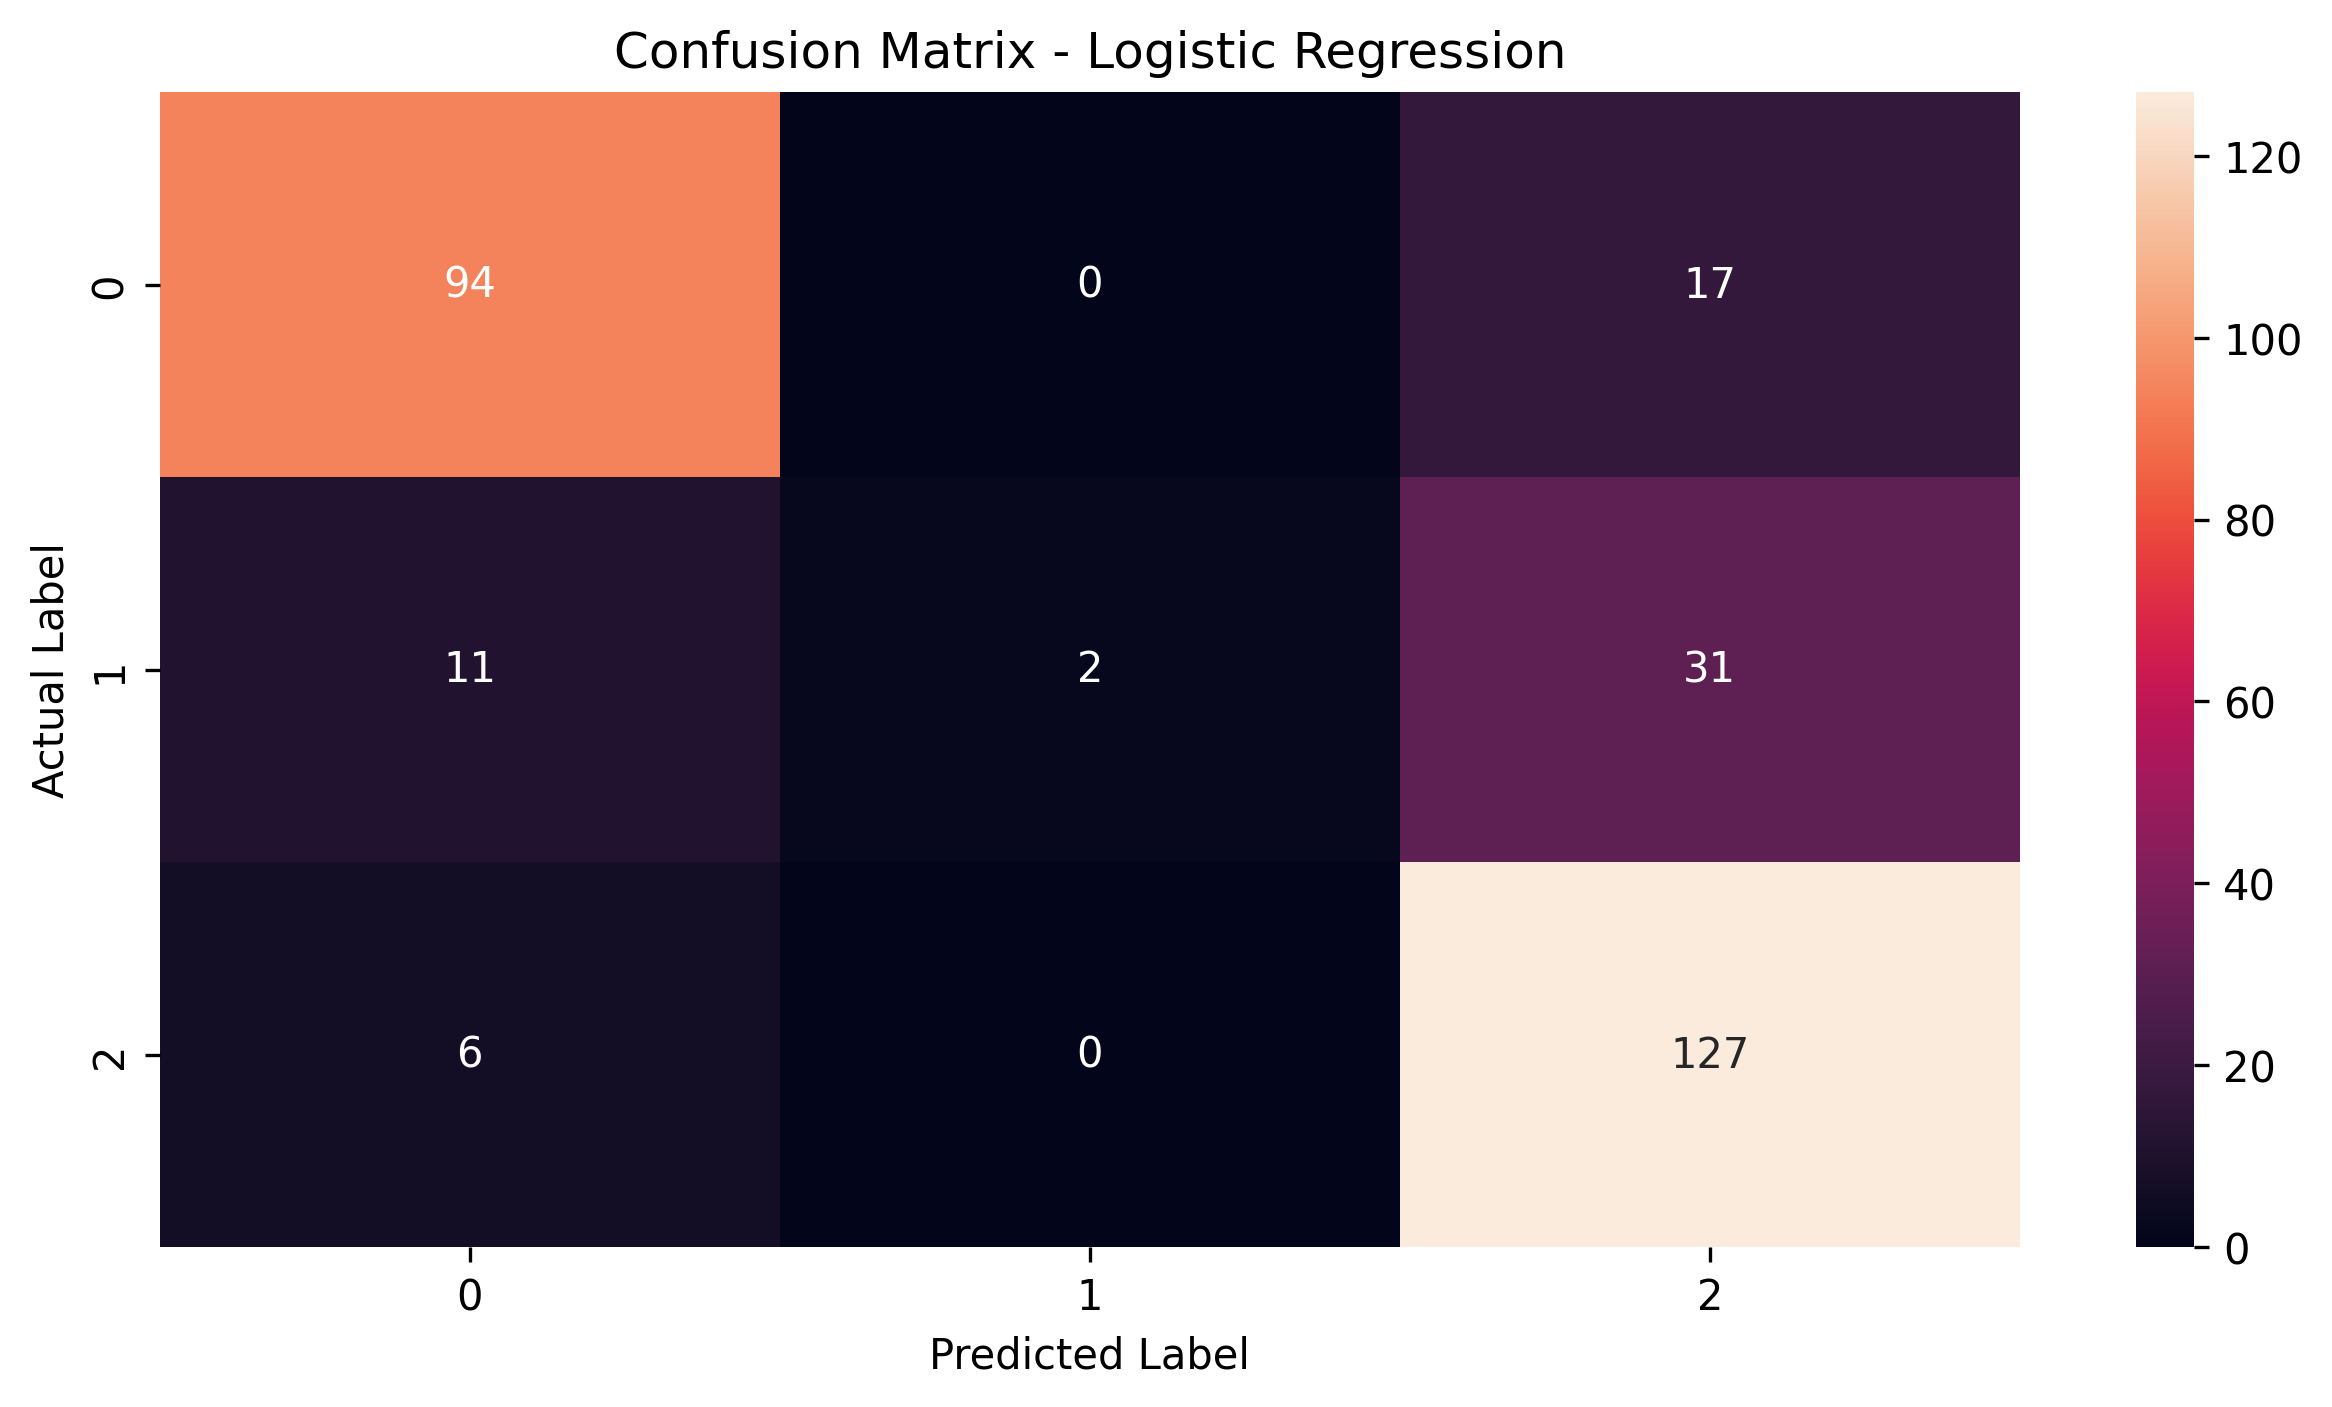

In [95]:
sns.heatmap(cm,annot=True,fmt='g')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**2**. **Multinomial Naive Bayes**

In [97]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(x_train, y_train)

y_pred_nb = nb_model.predict(x_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6805555555555556
              precision    recall  f1-score   support

           0       0.94      0.58      0.72       111
           1       0.00      0.00      0.00        44
           2       0.60      0.99      0.75       133

    accuracy                           0.68       288
   macro avg       0.51      0.52      0.49       288
weighted avg       0.64      0.68      0.62       288



In [98]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
print(cm_nb)

[[ 64   0  47]
 [  3   0  41]
 [  1   0 132]]


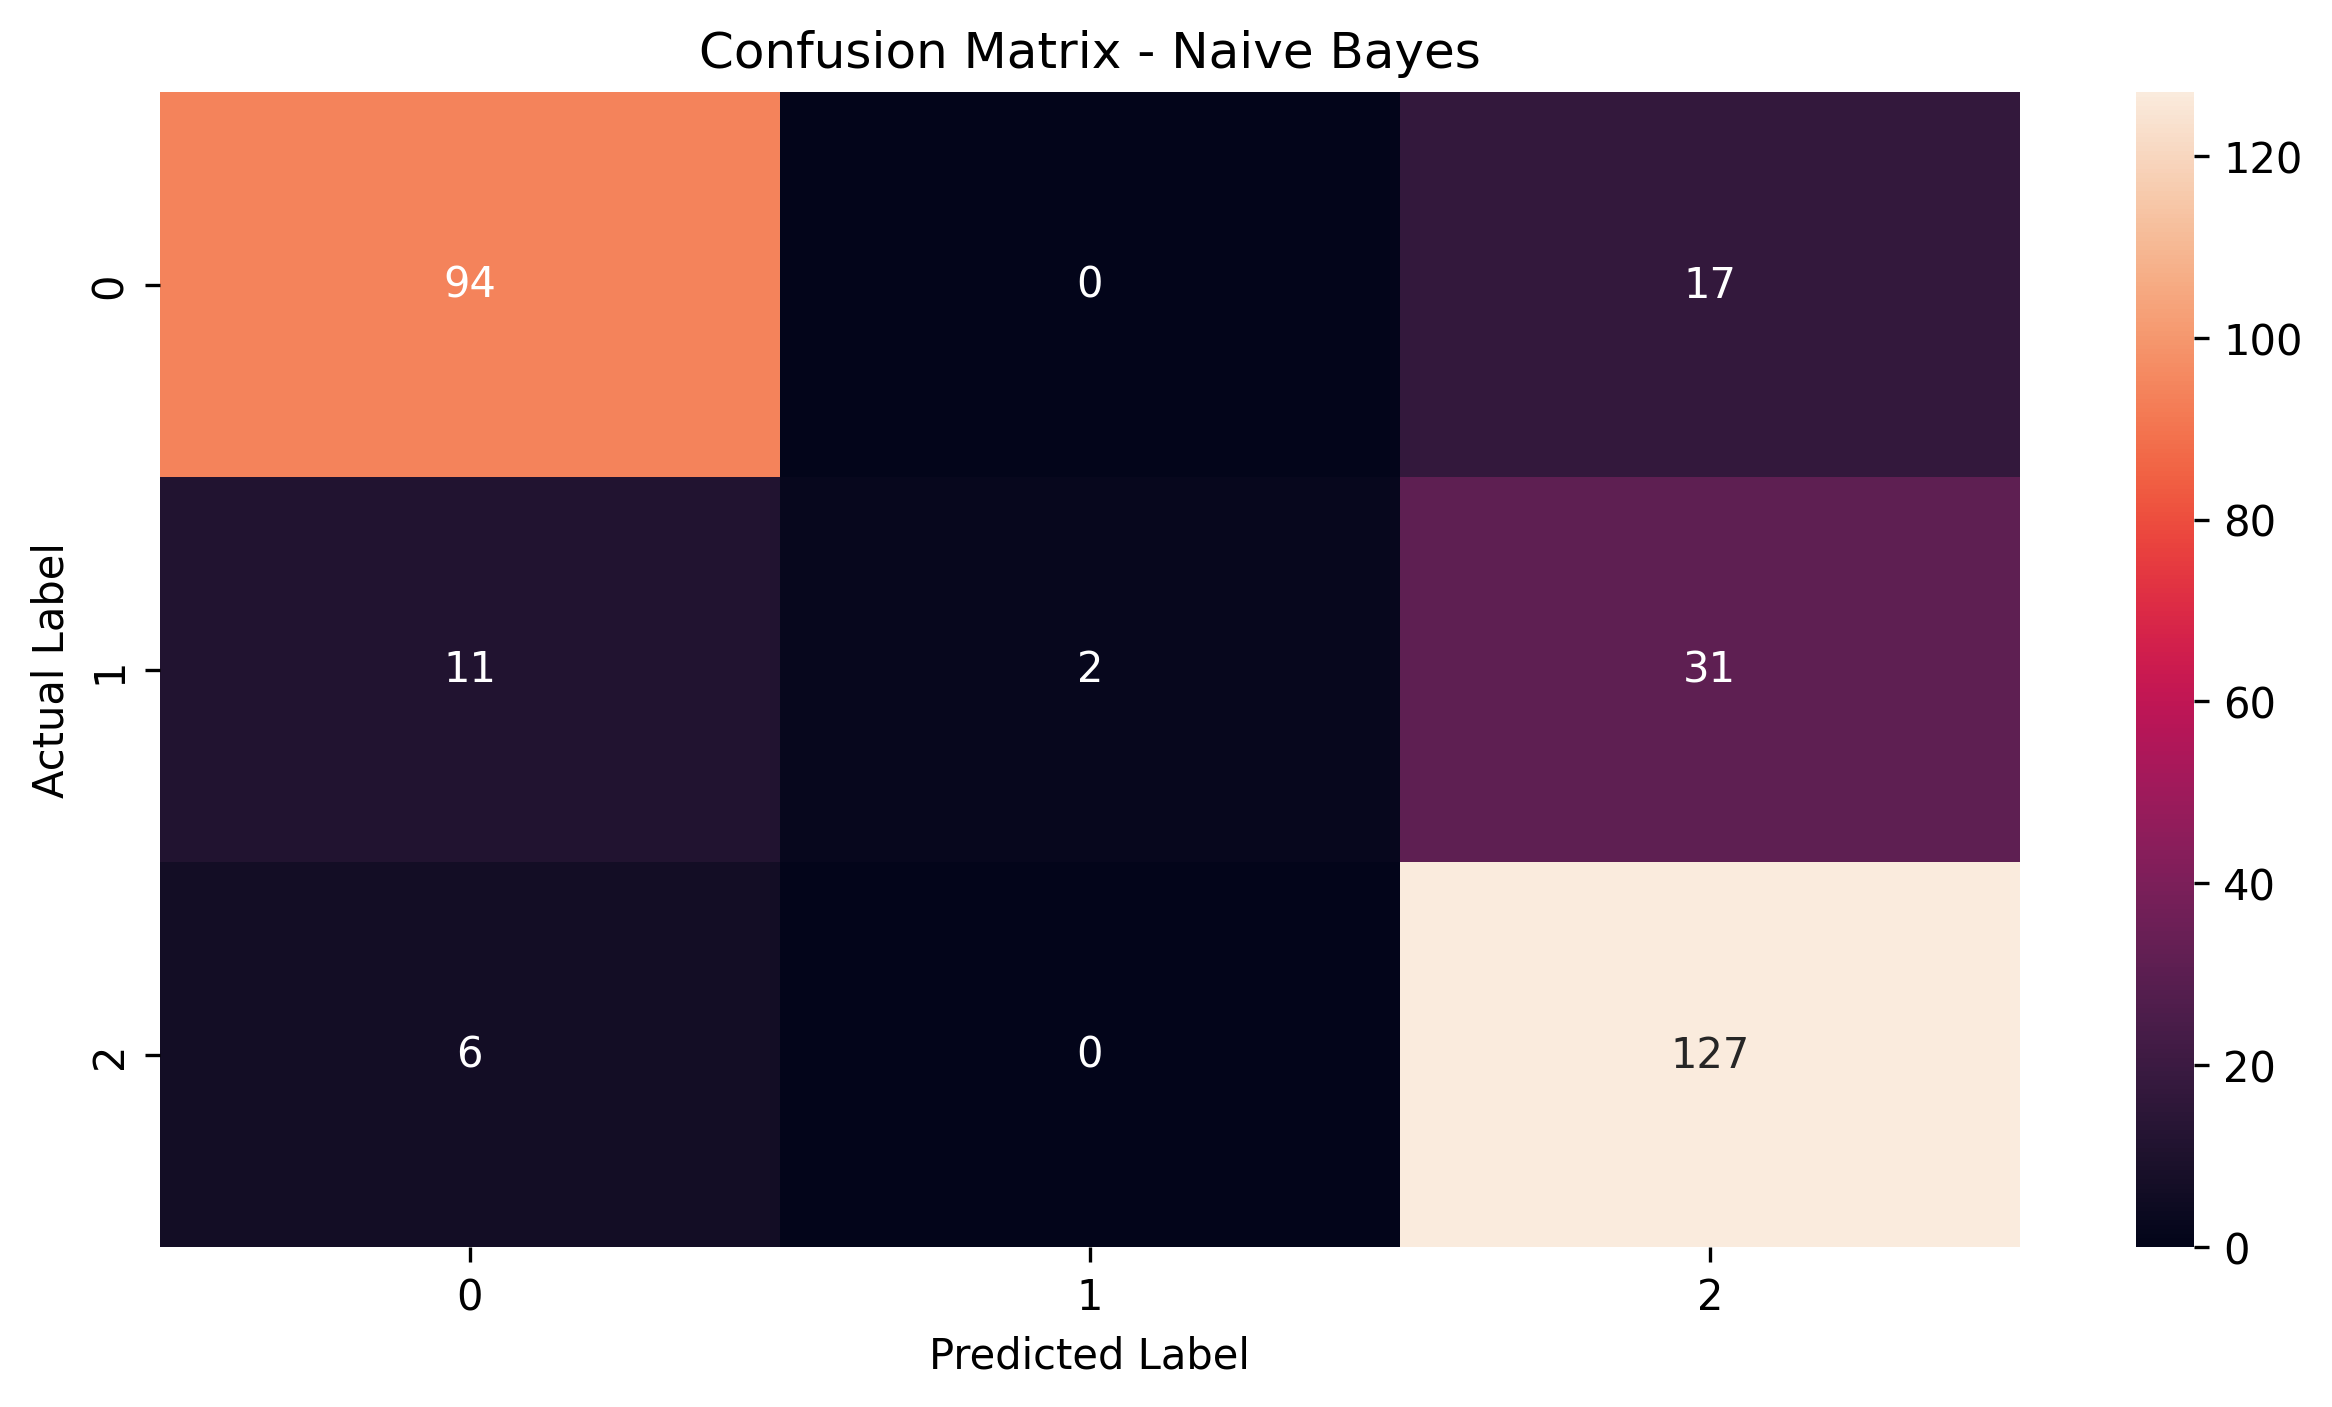

In [99]:
sns.heatmap(cm,annot=True,fmt='g')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

**3. Linear SVM**

In [100]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight='balanced', C=1.0)
# This tells the SVM to pay more attention to the minority classes

svm_model.fit(x_train, y_train)

y_pred_svm = svm_model.predict(x_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7673611111111112
              precision    recall  f1-score   support

           0       0.83      0.84      0.83       111
           1       0.46      0.25      0.32        44
           2       0.77      0.88      0.82       133

    accuracy                           0.77       288
   macro avg       0.69      0.66      0.66       288
weighted avg       0.75      0.77      0.75       288



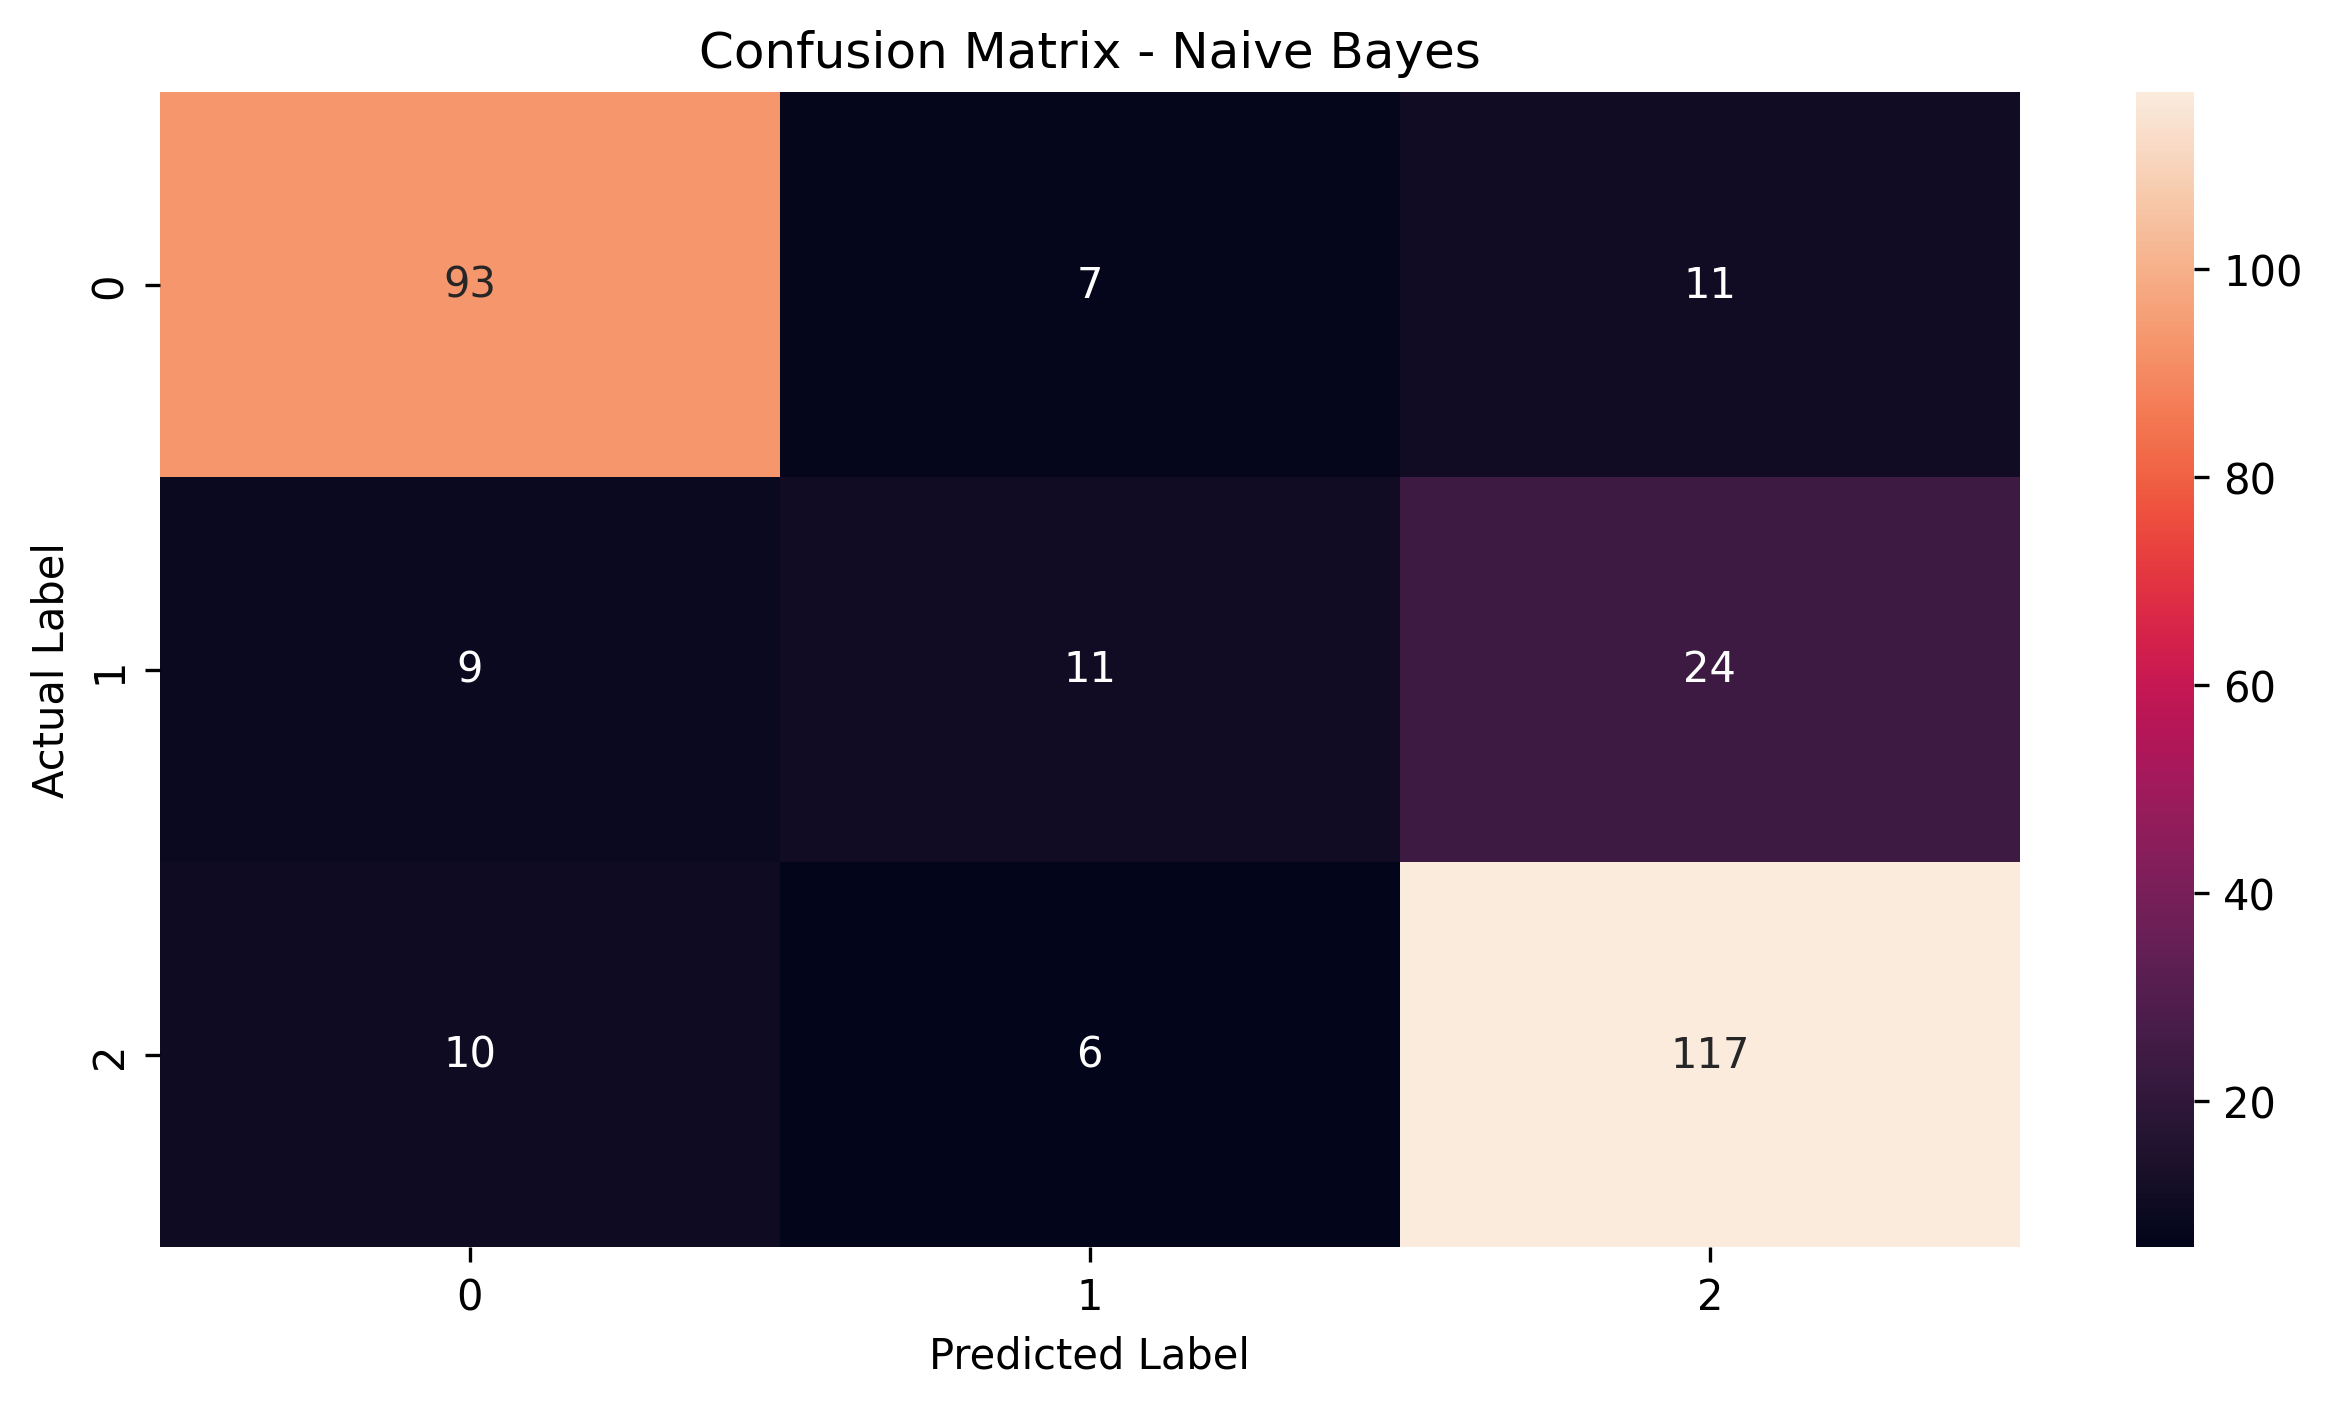

In [101]:
sns.heatmap(confusion_matrix(y_test, y_pred_svm),annot=True,fmt='g')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

**Hypertunning**

In [102]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

In [103]:
param_grid = {
  'C': [0.01, 0.1, 0.5, 1, 1.5, 2, 5],
  'class_weight': [None, 'balanced']
}

grid = GridSearchCV(LinearSVC(max_iter=5000), param_grid,cv=5,scoring='f1_macro',n_jobs=-1)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Parameters: {'C': 0.1, 'class_weight': 'balanced'}
Best CV Score: 0.5951884680823893
Test Accuracy: 0.7916666666666666
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       111
           1       0.67      0.18      0.29        44
           2       0.76      0.93      0.84       133

    accuracy                           0.79       288
   macro avg       0.76      0.66      0.66       288
weighted avg       0.78      0.79      0.76       288



In [104]:
results = pd.DataFrame({
    'Model': ['Logistic', 'Multinomial Naive Bayes', 'Linear SVM'],
    'Accuracy': [0.77,0.68,0.79],
    'F1 Score': [0.59,0.49,0.66]
})

In [105]:
results

,Model,Accuracy,F1 Score
0,Logistic,0.77,0.59
1,Multinomial Naive Bayes,0.68,0.49
2,Linear SVM,0.79,0.66


In [106]:
best_model = grid.best_estimator_
best_model


LinearSVC(C=0.1, class_weight='balanced', max_iter=5000)

# __Final Model Selection__

Best Model: Linear SVM

Reason:
- Highest F1-macro score
- Better handling of high dimensional sparse data
- Better generalization

Final F1 Score: 0.65
Final Accuracy: 79%

The 79% accuracy is due to limited data and the complexity of text, but the model performs well with a good balance between accuracy and F1 score.

Sentiment analysis is challenging because the same sentiment can be expressed differently. I focused on achieving a balance between accuracy and F1 score to ensure the model performs well across all classes.

## __Create Pickle File__

In [107]:
import pickle
pickle.dump(tfidf, open("tfidf.pkl", "wb"))
pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))

In [ ]:
from google.colab import files
files.download("Sentiment Analysis.pkl")
files.download("tfidf_vectorizer.pkl")
files.download("encoder.pkl")